# [Línea base] Competición de análisis de datos: Predicción del draft de la NFL

En este cuaderno, construirá un **modelo de línea base** para la tarea de predecir si un jugador será seleccionado en el Draft de la NFL (**Drafted**) basándose en los resultados de las pruebas de rendimiento deportivo y la información del jugador.

Un modelo de línea base es un modelo inicial simple construido para una tarea de aprendizaje automático determinada. Sirve como punto de partida para un mayor desarrollo del modelo y mejoras en el rendimiento.

Al ejecutar este cuaderno de principio a fin, generará un archivo de predicción que se puede enviar con éxito.

## Tabla de Contenidos
1. Configuración

2. Cargar los Datos

3. Análisis de Datos y EDA

4. Preprocesamiento

5. Modelo de Línea Base

6. Hipótesis e Ingeniería de Características

7. Crear el Archivo de Envío

8. Próximos Pasos

## 1. Configuración

In [432]:
# Import modules
import numpy as np  # Library for numerical computing and array operations
import pandas as pd  # Library for handling tabular data
import matplotlib.pyplot as plt  # Library for basic data visualization
import seaborn as sns  # Library for statistical data visualization
from sklearn.preprocessing import LabelEncoder  # Encoder for converting categorical variables to numeric labels
from sklearn.ensemble import RandomForestClassifier  # Random Forest classifier
from sklearn.model_selection import StratifiedKFold  # Class for stratified K-fold cross-validation
from sklearn.metrics import roc_auc_score  # Metric function for computing ROC AUC

En este cuaderno, asumimos la siguiente estructura de directorios en su Google Drive:
```
MyDrive/
└── GCI/
    └── competition/
        ├──README.ipynb
        ├── baseline.ipynb  # Este cuaderno (línea base)
        └── input/
            ├── train.csv  # Datos de entrenamiento
            ├── test.csv  # Datos de prueba (para predicción)
            └── sample_submission.csv  # Archivo de envío de muestra

```

## 2. Cargar los datos

### 2.1 Conectar con Google Drive
Para cargar los datos, primero necesitamos conectar este cuaderno de Colab con Google Drive.

In [433]:
# If you work with Google Colaboratory, please run this as well.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


A continuación, necesitamos navegar a donde se encuentra la carpeta `competition`.

**IMPORTANTE**:
Cambie la ruta en el comando `%cd` a continuación para que coincida con la carpeta donde está guardado este cuaderno en Google Drive **reemplazando "WhereThisNotebookIsLocated" con la ruta de su carpeta real**.

Ejemplos:
- Ha subido la carpeta `competition` directamente en MyDrive (la carpeta predeterminada cuando abre Google Drive)
    - Cambie a "/<wbr>content/drive/MyDrive/competition"
- Ha subido la carpeta `competition` dentro de una carpeta llamada `00_GCIGlobal` en MyDrive
    - Cambie a "/<wbr>content/drive/MyDrive/00_GCIGlobal/competition"

Puede localizar fácilmente el directorio de su cuaderno:
1. Abra el panel de Archivos en el lado izquierdo de Colab
2. Navegue por las carpetas "drive" y "MyDrive" hasta encontrar las carpetas de su cuaderno
3. Haga clic en el icono de más acciones (tres puntos verticales, $\vdots$) junto al nombre de la carpeta
4. Seleccione la opción "Copiar ruta"

In [434]:
# Specify the directory where this notebook is located after %cd.
%cd "/content/drive/MyDrive/Colab Notebooks/JAPONES/competition"

/content/drive/MyDrive/Colab Notebooks/JAPONES/competition


![Screenshot 2025-10-27 at 15.21.34.png]([Media removed: image/png, ~454684 chars])

Ejecute la celda siguiente para comprobar si la ruta está configurada correctamente.

In [435]:
from pathlib import Path

PATH = Path.cwd() / "input"

train_file = PATH / "train.csv"
test_file = PATH / "test.csv"
sample_sub_file = PATH / "sample_submission.csv"

# Check if path exists
if train_file.exists() and test_file.exists() and sample_sub_file.exists():
    print("All files exist and path is correctly set.")
else:
    print("Some files are missing or path is not correctly set.")

All files exist and path is correctly set.


### 2.2 Resumen de los Datos
Ejecute la celda para cargar el conjunto de datos como `pd.DataFrame`.

**IMPORTANTE:**<br>
**Cuando realice modificaciones en el preprocesamiento o el entrenamiento del modelo, asegúrese siempre de ejecutar todas las celdas desde esta celda.**

In [436]:
PATH = Path.cwd() / "input"

train = pd.read_csv(PATH / "train.csv")
test = pd.read_csv(PATH / "test.csv")
sample_sub = pd.read_csv(PATH / "sample_submission.csv")

print(f"train: {train.shape}, test: {test.shape}, sample_sub: {sample_sub.shape}")

train: (2781, 16), test: (696, 15), sample_sub: (696, 2)


In [ ]:
train['Drafted'] = train['Drafted'].astype(int)
print("Converted 'Drafted' column to integer type (0 or 1).")

Primero, comprobemos la forma del conjunto de datos.

In [438]:
print('Train:', train.shape)
print('Test:', test.shape)

Train: (2781, 16)
Test: (696, 15)


Podemos ver que los datos de entrenamiento contienen **2,781 filas** y **16 columnas**, mientras que los datos de prueba contienen **696 filas** y **15 columnas**.
Los datos de prueba tienen una columna menos porque no incluyen la variable objetivo a predecir.

A continuación, veamos las **cinco primeras filas** de los datos de entrenamiento.

In [439]:
train.head()

,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1
1,1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1
2,2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1
3,3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1
4,4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1


Puede ver información detallada sobre un DataFrame de pandas usando `.info()`.

In [440]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2781 entries, 0 to 2780
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                2781 non-null   int64  
 1   Year              2781 non-null   int64  
 2   Age               2346 non-null   float64
 3   School            2781 non-null   object 
 4   Height            2781 non-null   float64
 5   Weight            2781 non-null   float64
 6   Sprint_40yd       2636 non-null   float64
 7   Vertical_Jump     2227 non-null   float64
 8   Bench_Press_Reps  2060 non-null   float64
 9   Broad_Jump        2200 non-null   float64
 10  Agility_3cone     1811 non-null   float64
 11  Shuttle           1869 non-null   float64
 12  Player_Type       2781 non-null   object 
 13  Position_Type     2781 non-null   object 
 14  Position          2781 non-null   object 
 15  Drafted           2781 non-null   int64  
dtypes: float64(9), int64(3), object(4)
memory 

### [Próximos Pasos]

Esta sección solo cargó los datos. Algunos puntos de partida fáciles para profundizar antes de la EDA:

- Ejecute `train.describe()` y `test.describe()` para ver las estadísticas resumidas de las columnas numéricas.
- Compruebe si hay filas duplicadas con `train.duplicated().sum()`.
- Compare las estadísticas básicas (media, desviación estándar, mínimo, máximo) entre **train** y **test** para comprobar si las dos divisiones se ven similares.

In [441]:
train.describe()

,Id,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Drafted
count,2781.000000,2781.000000,2346.000000,2781.000000,2781.000000,2636.000000,2227.000000,2060.000000,2200.000000,1811.000000,1869.000000,2781.000000
mean,1390.000000,2013.838907,21.997016,1.873590,109.502026,4.764818,83.506349,20.236408,291.985700,7.230447,4.399422,0.648328
std,802.949874,3.083247,0.964836,0.067178,20.307239,0.299343,10.710691,6.410662,23.924666,0.410686,0.263851,0.477578
min,0.000000,2009.000000,18.000000,1.651000,67.585263,4.220000,44.450000,2.000000,198.120000,6.280000,3.820000,0.000000
25%,695.000000,2011.000000,21.000000,1.828800,92.986436,4.530000,76.200000,16.000000,276.860000,6.930000,4.200000,0.000000
50%,1390.000000,2014.000000,22.000000,1.879600,104.779837,4.680000,83.820000,20.000000,294.640000,7.130000,4.350000,1.000000
75%,2085.000000,2017.000000,23.000000,1.930400,124.284309,4.950000,91.440000,24.000000,307.340000,7.490000,4.560000,1.000000
max,2780.000000,2019.000000,28.000000,2.082800,162.386068,6.000000,114.300000,45.000000,373.380000,9.040000,5.560000,1.000000


In [442]:
test.describe()

,Id,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle
count,696.000000,696.000000,581.000000,696.000000,696.000000,667.000000,553.000000,512.000000,549.000000,449.000000,468.000000
mean,3128.500000,2013.762931,21.927711,1.875476,110.722810,4.785922,82.933526,20.259766,290.203097,7.265523,4.421496
std,201.062179,3.046376,0.986953,0.068770,21.161295,0.309420,10.544504,6.842719,24.074513,0.407634,0.270203
min,2781.000000,2009.000000,19.000000,1.676400,76.657111,4.280000,52.070000,6.000000,210.820000,6.500000,3.810000
25%,2954.750000,2011.000000,21.000000,1.828800,92.986436,4.540000,74.930000,15.000000,276.860000,6.980000,4.220000
50%,3128.500000,2014.000000,22.000000,1.879600,104.779837,4.700000,83.820000,20.000000,294.640000,7.180000,4.380000
75%,3302.250000,2016.000000,23.000000,1.930400,131.995380,5.005000,90.170000,25.000000,307.340000,7.500000,4.592500
max,3476.000000,2019.000000,27.000000,2.032000,167.375585,5.760000,111.760000,49.000000,345.440000,8.720000,5.380000


In [443]:
# Verificando si hay duplicados
duplicados = train.duplicated().sum()
print(f"Número de líneas duplicadas: {duplicados}")


Número de líneas duplicadas: 0


In [444]:
train_stats = train.describe().T
test_stats = test.describe().T

comparison = train_stats[['mean', 'std', 'min', 'max']].join(
    test_stats[['mean', 'std', 'min', 'max']],
    lsuffix='_train',
    rsuffix='_test'
)

display(comparison)

,mean_train,std_train,min_train,max_train,mean_test,std_test,min_test,max_test
Id,1390.000000,802.949874,0.000000,2780.000000,3128.500000,201.062179,2781.000000,3476.000000
Year,2013.838907,3.083247,2009.000000,2019.000000,2013.762931,3.046376,2009.000000,2019.000000
Age,21.997016,0.964836,18.000000,28.000000,21.927711,0.986953,19.000000,27.000000
Height,1.873590,0.067178,1.651000,2.082800,1.875476,0.068770,1.676400,2.032000
Weight,109.502026,20.307239,67.585263,162.386068,110.722810,21.161295,76.657111,167.375585
Sprint_40yd,4.764818,0.299343,4.220000,6.000000,4.785922,0.309420,4.280000,5.760000
Vertical_Jump,83.506349,10.710691,44.450000,114.300000,82.933526,10.544504,52.070000,111.760000
Bench_Press_Reps,20.236408,6.410662,2.000000,45.000000,20.259766,6.842719,6.000000,49.000000
Broad_Jump,291.985700,23.924666,198.120000,373.380000,290.203097,24.074513,210.820000,345.440000
Agility_3cone,7.230447,0.410686,6.280000,9.040000,7.265523,0.407634,6.500000,8.720000


#### Resultados de la comparacion
Validación y Comparación de Conjuntos de Entrenamiento y PruebaTras realizar la partición del conjunto de datos en entrenamiento (Train) y prueba (Test), se presenta el siguiente análisis de validación para garantizar que ambos conjuntos sean homogéneos y representativos, evitando sesgos en el posterior entrenamiento del modelo.
#####1. Variables Demográficas y Físicas
 - **Year (Año):** Ambos conjuntos cubren exactamente el mismo rango de tiempo (2009 a 2019). Las medias ($\approx 2013.8$) y las desviaciones estándar ($\approx 3.0$) son prácticamente idénticas, lo que asegura que no hay sesgo temporal.
 - **Age (Edad):** La edad promedio ronda los 22 años en ambos grupos. Cabe notar que el conjunto de Test no incluye el valor mínimo absoluto de 18 años (su mínimo es 19), pero las distribuciones generales se mantienen sumamente alineadas.
 - **Height y Weight (Altura y Peso) :** Los promedios físicos son consistentes (Altura: $\approx 1.87$ m; Peso: $\approx 109.5$ kg en Train vs. $110.7$ kg en Test). El Índice de Masa Corporal (BMI) refleja esta misma consistencia con una media de $\approx 31.0$ en ambos lados.
 ##### 2. Pruebas Atléticas (Combine Performance)
 Las métricas de rendimiento físico muestran un comportamiento casi espejo entre ambos datasets:Sprint_40yd: Media de $4.76$s (Train) vs. $4.78$s (Test).Vertical_Jump: Media de $83.50$ cm (Train) vs. $83.05$ cm (Test).Bench_Press_Reps: Promedio de $\approx 20.2$ repeticiones para ambos.Broad_Jump, Agility_3cone y Shuttle: Todos presentan variaciones marginales en sus medias y desviaciones estándar, lo que demuestra que las habilidades atléticas están distribuidas de manera uniforme.
 ##### 3. Variables Categóricas (Player, Position_Type, Position)
 Las variables de control y segmentación (Player_Type, Position_Type, Position) mantienen proporciones muy similares. Las medias y desviaciones estándar se comportan de manera equivalente, lo que confirma que la distribución de posiciones y tipos de jugador no se vio afectada por la partición.4. Variable Objetivo (Drafted)Drafted: Como es correcto y esperado en un flujo de trabajo de Machine Learning, la variable objetivo solo presenta datos en el conjunto de entrenamiento (Media: $0.648$, lo que indica que aproximadamente el 64.8% de los jugadores en Train fueron seleccionados). En el conjunto de prueba, aparece como NaN, validando que se ha reservado correctamente para la evaluación a ciegas del modelo.

## 3. Análisis de Datos y EDA

**EDA (Análisis Exploratorio de Datos)** es un paso esencial para comprender la estructura y las características de sus datos antes de construir un modelo.

En esta etapa, explora tendencias y patrones en el conjunto de datos, así como **valores atípicos**, **valores perdidos** y **distribuciones desequilibradas**. Por ejemplo, algunas variables pueden contener valores extremos o los datos pueden estar muy sesgados hacia categorías específicas. La identificación de estas características le ayuda a encontrar posibles problemas que podrían perjudicar el rendimiento y a descubrir características que pueden ser útiles para la predicción.

Al realizar EDA, puede detectar y abordar problemas tempranamente, como "el entrenamiento falla debido a valores perdidos" o "el modelo se vuelve inestable debido a valores atípicos". Esto reduce el retrabajo posterior y permite un preprocesamiento e ingeniería de características más eficientes.

Los conocimientos de EDA también influyen en decisiones posteriores, incluida la selección del modelo y el ajuste de hiperparámetros. En las competiciones de aprendizaje automático, EDA es a menudo un proceso clave para mejorar las puntuaciones finales.

### 3.1 Comprobación de Valores Faltantes

Primero, verifiquemos los valores faltantes. Este es un paso esencial en el análisis de datos basado en el aprendizaje automático, porque la mayoría de los modelos de aprendizaje automático no pueden entrenar o hacer predicciones a partir de datos que contienen valores faltantes, y generarán un error.

In [445]:
train.isnull().sum()

,0
Id,0
Year,0
Age,435
School,0
Height,0
Weight,0
Sprint_40yd,145
Vertical_Jump,554
Bench_Press_Reps,721
Broad_Jump,581


In [446]:
test.isnull().sum()

,0
Id,0
Year,0
Age,115
School,0
Height,0
Weight,0
Sprint_40yd,29
Vertical_Jump,143
Bench_Press_Reps,184
Broad_Jump,147


In [447]:
valores_en_blanco_o_vacio = train.apply(lambda x: x.astype(str).str.strip() == '').sum()
print("\nValores en blanco o string vacios por columna:")
print(valores_en_blanco_o_vacio[valores_en_blanco_o_vacio > 0])


Valores en blanco o string vacios por columna:
Series([], dtype: int64)


Encontramos valores faltantes en las siguientes columnas: **Age**, **Sprint_40yd**, **Vertical_Jump**, **Bench_Press_Reps**, **Broad_Jump**, **Agility_3cone** y **Shuttle**. Los manejaremos más tarde.

### 3.2 Visualización y Análisis

A continuación, veamos cuántos jugadores fueron seleccionados en el draft.

In [448]:
train['Drafted'].value_counts(normalize=True)

,proportion
Drafted,
1,0.648328
0,0.351672


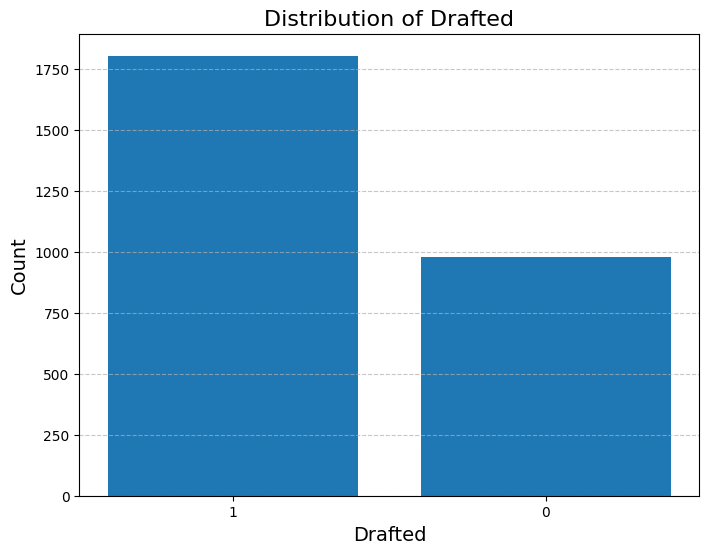

In [449]:
drafted_counts = train['Drafted'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(drafted_counts.index.astype(str), drafted_counts.values)
plt.title('Distribution of Drafted', fontsize=16)
plt.xlabel('Drafted', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Podemos ver que hay más jugadores con **Drafted = 1** que con **Drafted = 0**. Veamos las proporciones.

In [450]:
drafted_percentage = train['Drafted'].value_counts(normalize=True) * 100

print(f"Percentage of 0: {drafted_percentage.get(0, 0):.2f}%")
print(f"Percentage of 1: {drafted_percentage.get(1, 0):.2f}%")

Percentage of 0: 35.17%
Percentage of 1: 64.83%


Encontramos que aproximadamente el **35%** de los jugadores **no fueron seleccionados**, mientras que aproximadamente el **65%** **sí lo fueron**.

A continuación, continuaremos con el EDA para las otras características. Primero, visualicemos las variables numéricas excluyendo las columnas **"Id"** y **"Drafted"**.

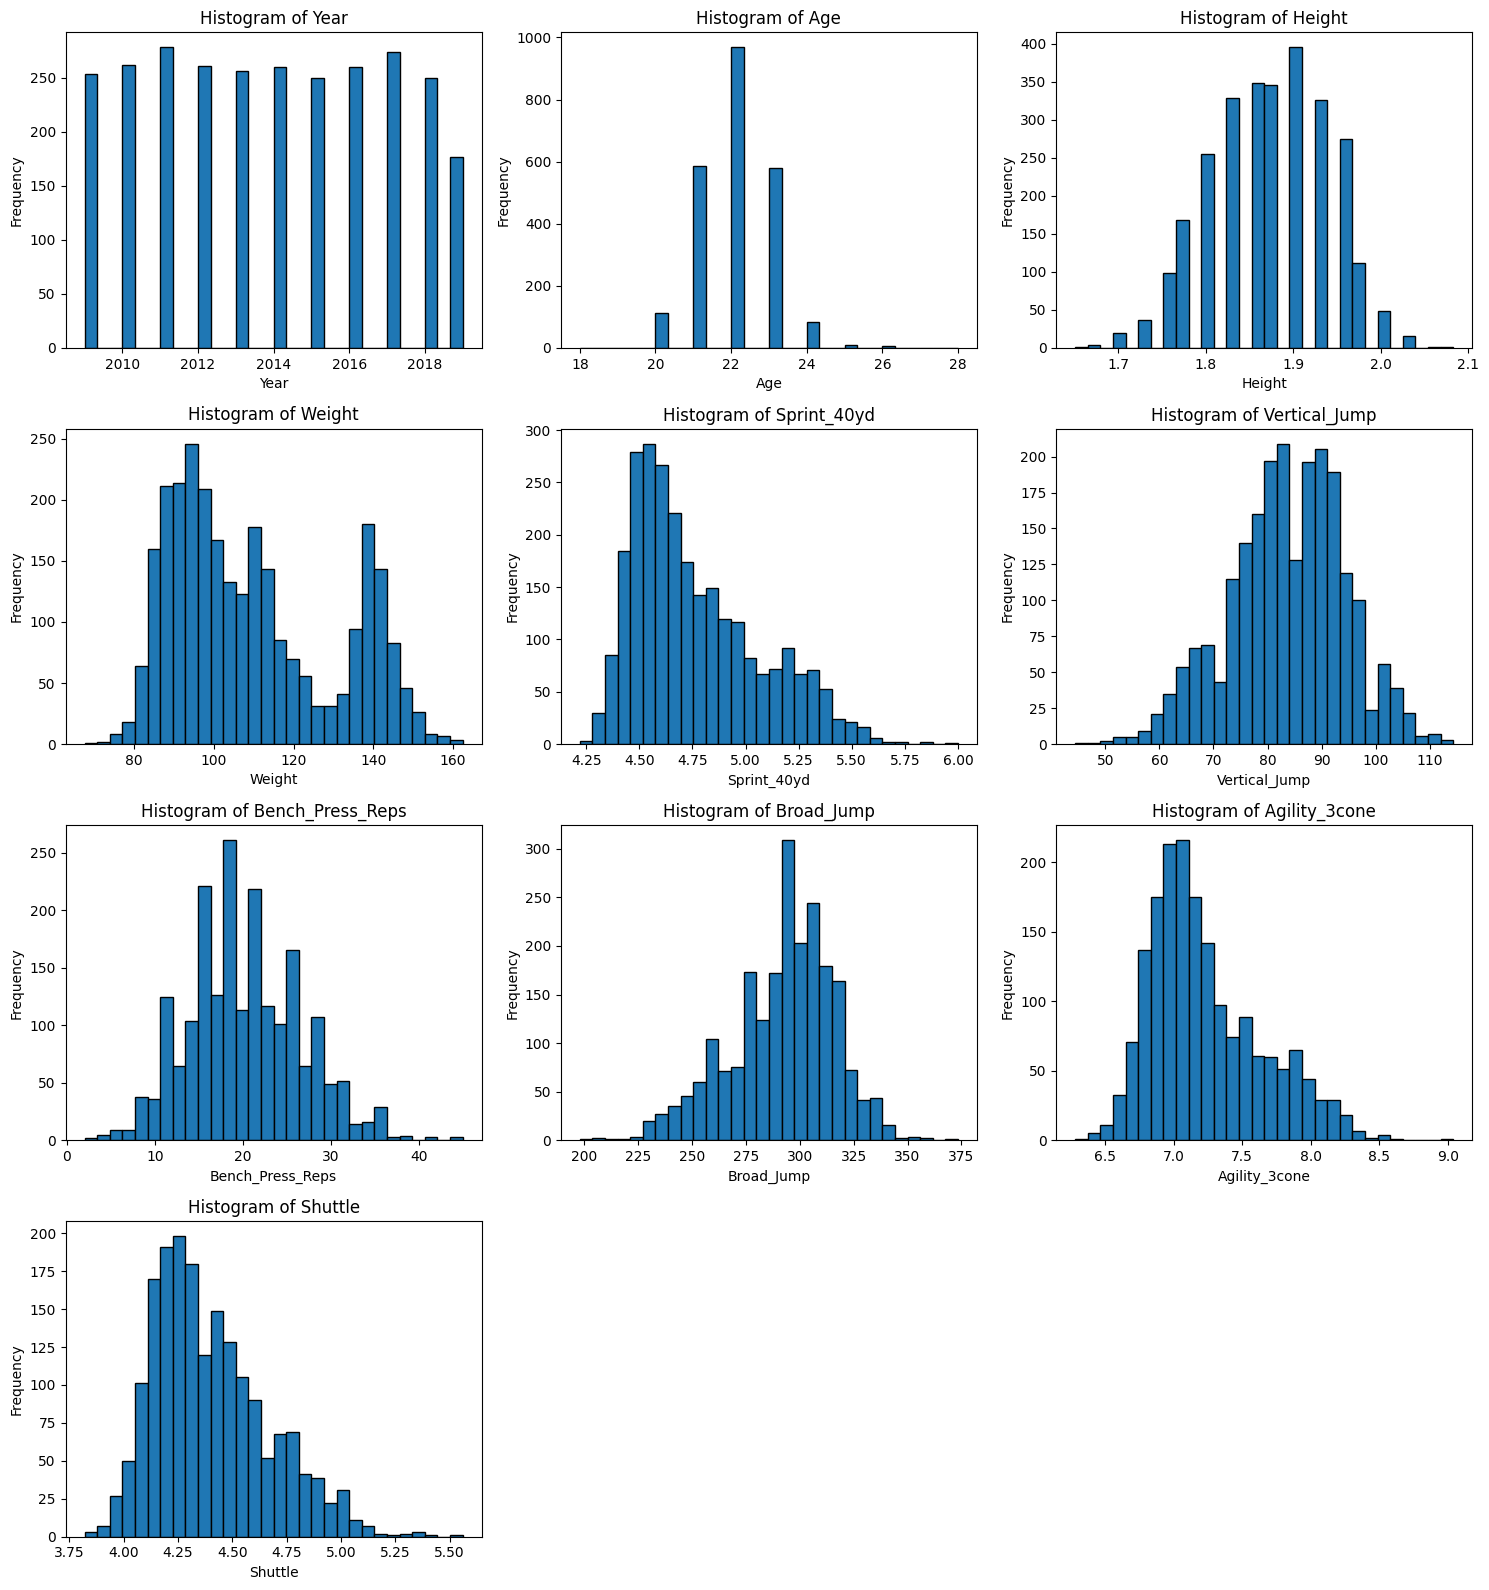

In [451]:
# Extraxt numeric columns (excluding the 'Id' and 'Drafted' columns)
numeric_cols = train.select_dtypes(include=['number']).columns
numeric_cols = numeric_cols.drop(['Id', 'Drafted'])

# Plot
num_cols = len(numeric_cols)
cols = 3
rows = (num_cols + cols - 1) // cols

plt.figure(figsize=(5 * cols, 4 * rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    plt.hist(train[col].dropna(), bins=30, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Examinemos la matriz de correlación de las características numéricas usando un mapa de calor.

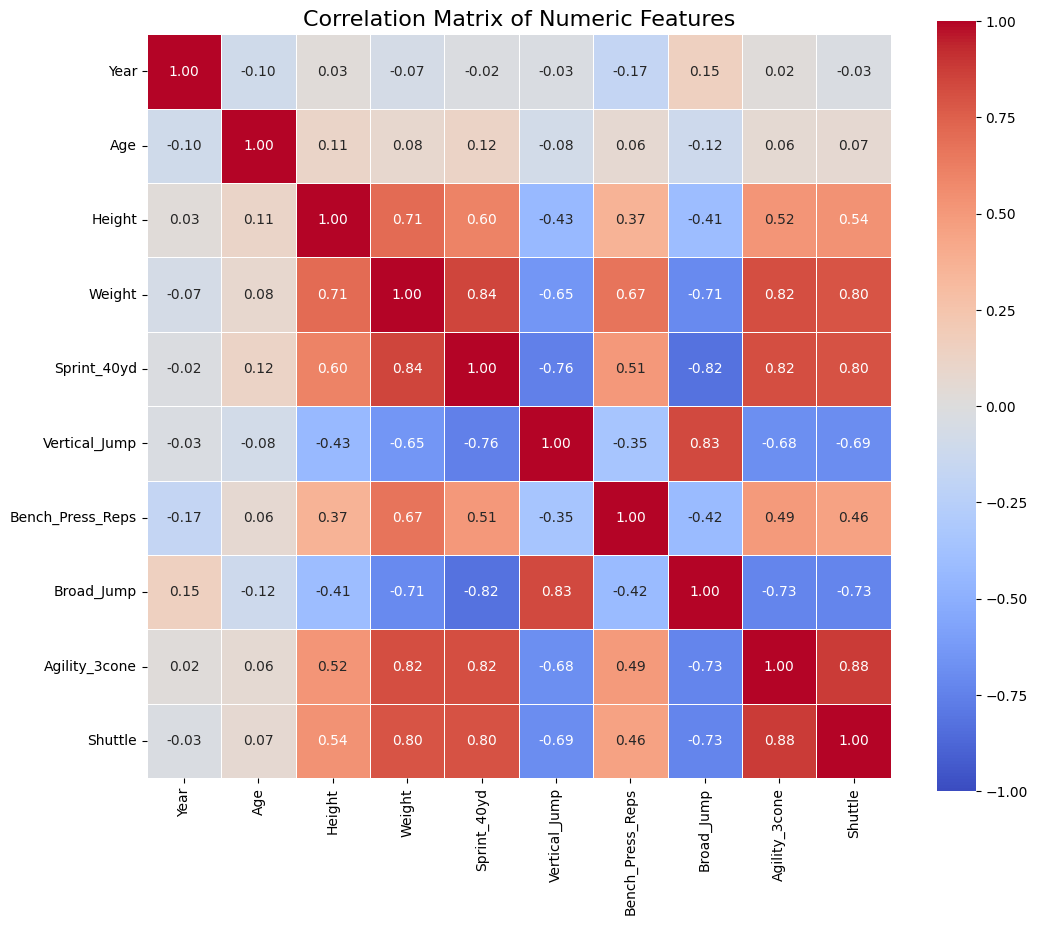

In [452]:
# Extract numeric columns (excluding the 'Id' and ''Drafted' columns)
numeric_cols = train.select_dtypes(include=['number']).drop(['Id', 'Drafted'], axis=1)

# Compute the correlation matrix
corr_matrix = numeric_cols.corr()

# Plot a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.show()

El coeficiente de correlación entre **Agility_3cone** y **Shuttle** es de **0.88**, lo que indica una fuerte relación positiva. Estas pruebas pueden depender de grupos musculares y patrones de movimiento similares.

Por otro lado, el coeficiente de correlación entre **Sprint_40yd** y **Broad_Jump** es de **-0.82**, mostrando una fuerte relación negativa. Dado que ambos eventos dependen principalmente de la potencia de la parte inferior del cuerpo, normalmente podríamos esperar que sus puntuaciones se muevan juntas (es decir, una correlación positiva), pero aquí observamos lo contrario. Para investigar esto más a fondo, visualicemos **Sprint_40yd**.

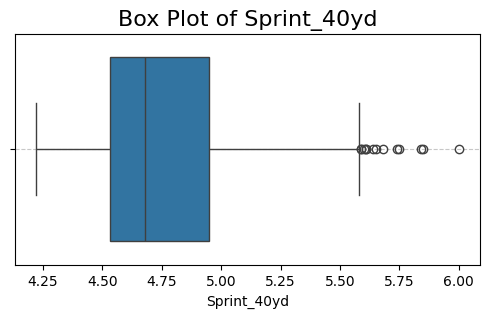

In [453]:
# Plot a boxplot
plt.figure(figsize=(6, 3))
sns.boxplot(x=train['Sprint_40yd'])

plt.title('Box Plot of Sprint_40yd', fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Del gráfico, podemos ver que los valores en **Sprint_40yd** se distribuyen aproximadamente entre **4.25** y **6.00**. Esto sugiere que la columna probablemente representa el **tiempo real de sprint**, no una "puntuación". Una mediana de alrededor de **4.7 segundos** es razonable para una carrera de 40 yardas (unos 36 metros).

En otras palabras, **valores más pequeños** en **Sprint_40yd** significan tiempos más rápidos, por lo que **menos es mejor**, la dirección opuesta a las métricas donde **valores más altos indican un mejor rendimiento**. Esto explica por qué observamos una correlación negativa con **Broad_Jump**.

Al visualizar los datos, pudimos responder a la pregunta: **"¿Por qué hay una correlación negativa?"**

A continuación, visualicemos las características categóricas.

In [454]:
# Extract categorical features
categorical_cols = train.select_dtypes(include=['object', 'category']).columns

# Get the number of unique categories in each column
levels_count = {col: train[col].nunique() for col in categorical_cols}

for col, count in levels_count.items():
    print(f"{col}: {count} levels")


School: 236 levels
Player_Type: 3 levels
Position_Type: 7 levels
Position: 20 levels


**'School'** tiene **236** valores únicos, lo cual es demasiado para visualizar claramente, por lo que lo excluiremos de los gráficos aquí.

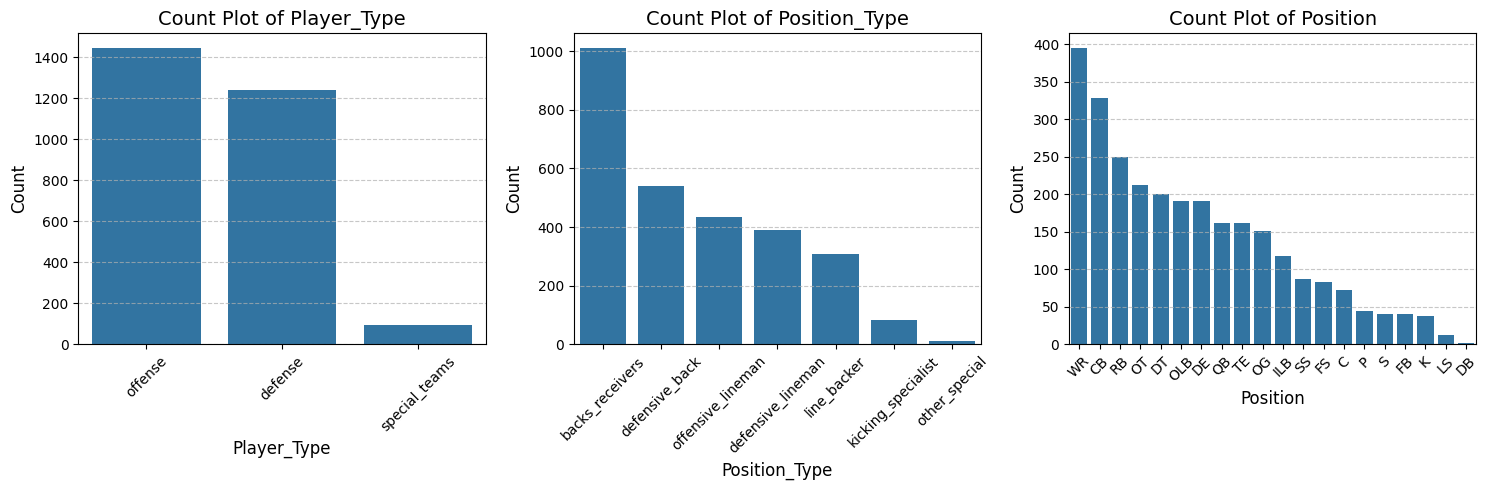

In [455]:
# Extract categorical features (object or category) and exclude the 'School' columns
categorical_cols = train.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop('School')

# Prepare for plotting
num_cols = len(categorical_cols)
rows = 1
cols = num_cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5))

if cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Count plots for each categorical features
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=train, order=train[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Podemos ver que el número de muestras varía ampliamente entre categorías. Por ejemplo, en la columna **Player_Type**, la categoría **special_teams** tiene muy pocas muestras.

A continuación, visualicemos el **valor medio de "Drafted"** para cada nivel de categoría. Esto nos ayuda a entender, visualmente, qué posiciones tienen más probabilidades de ser seleccionadas.

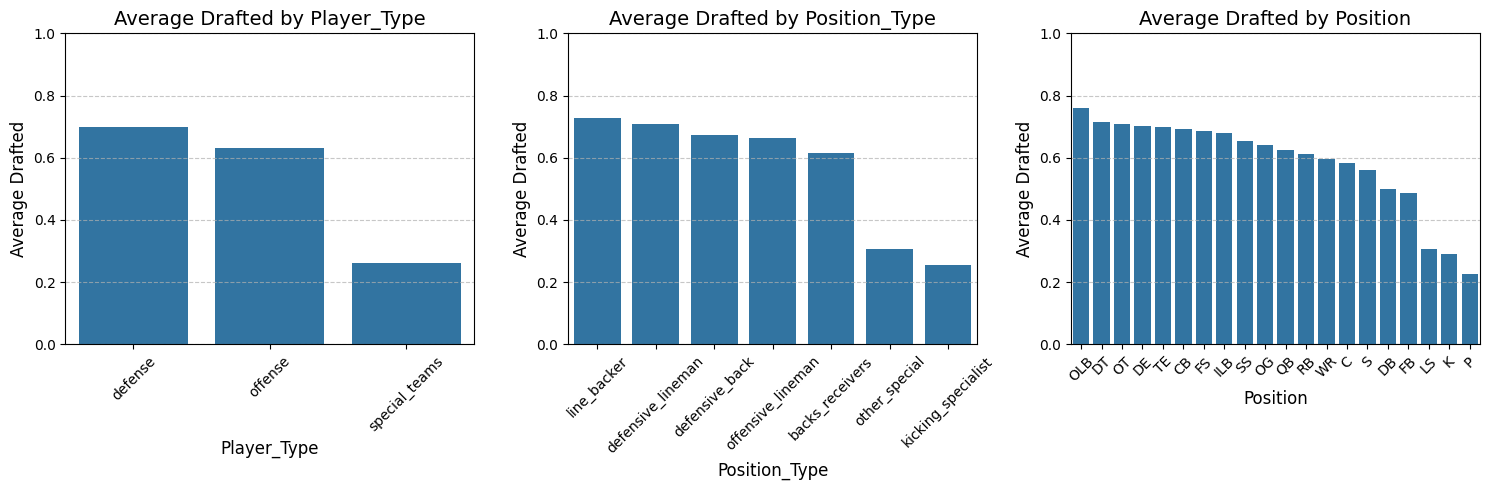

In [456]:
# Extract categorical features (object or category) and exclude the 'School' column
categorical_cols = train.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop('School')

# Prepare for plotting
num_cols = len(categorical_cols)
rows = 1
cols = num_cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5))

if cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Plot the mean value of 'Drafted' for each categorical feature as bar charts
for i, col in enumerate(categorical_cols):
    mean_values = train.groupby(col)['Drafted'].mean().sort_values(ascending=False)
    sns.barplot(x=mean_values.index, y=mean_values.values, ax=axes[i])
    axes[i].set_title(f'Average Drafted by {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Average Drafted', fontsize=12)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Podemos ver que los jugadores con **Player_Type = "special_teams"** tienen una tasa de draft mucho más baja que otros jugadores.
De manera similar, los jugadores con **Position_Type = "other_special"** o **"kicking_specialist"**, y aquellos con **Position = "LS"**, **"K"**, o **"P"**, también tienen tasas de draft relativamente bajas.

### [Próximos Pasos]

El EDA es abierto; aquí hay algunas direcciones que puede tomar a continuación:

- Examine la relación entre cada característica numérica y el objetivo con diagramas de caja agrupados (`sns.boxplot(x='Drafted', y=col, ...)`).
- Tabule las características categóricas contra **Drafted** para ver qué categorías tienen una tasa de draft alta o baja.
- Investigue la columna **School** con más cuidado; por ejemplo, agrupe las escuelas por conferencia o región y verifique la tasa de draft por grupo.
- Busque valores atípicos en otras columnas numéricas (por ejemplo, **Bench_Press_Reps**, **Vertical_Jump**) y decida cómo manejarlos.

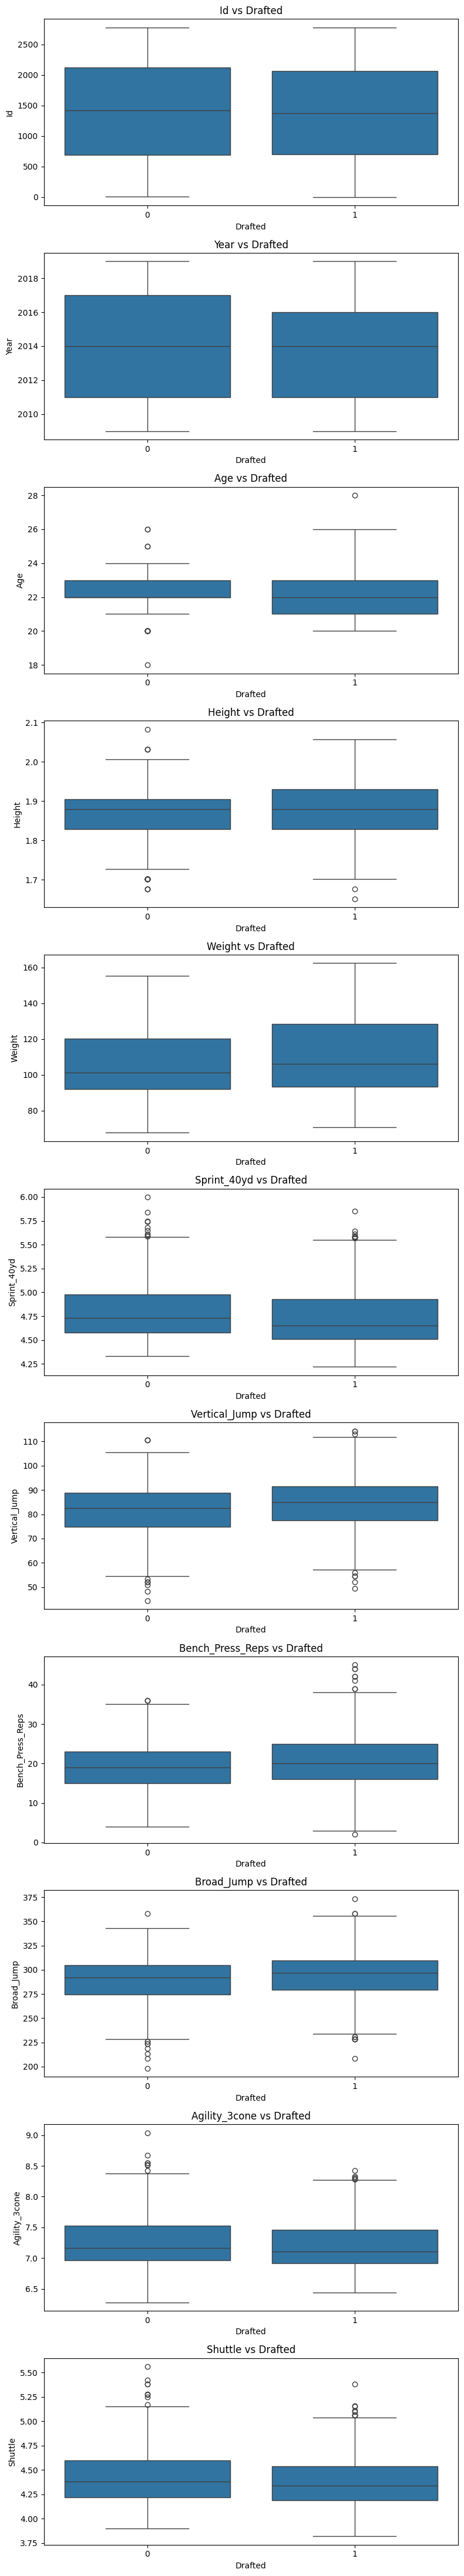

In [457]:
numeric_cols = train.select_dtypes(include='number').columns.drop('Drafted')
fig, axes = plt.subplots(len(numeric_cols), 1,
                         figsize=(8, 4*len(numeric_cols)))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x='Drafted', y=col, data=train, ax=ax)
    ax.set_title(f'{col} vs Drafted')

plt.tight_layout()
plt.show()

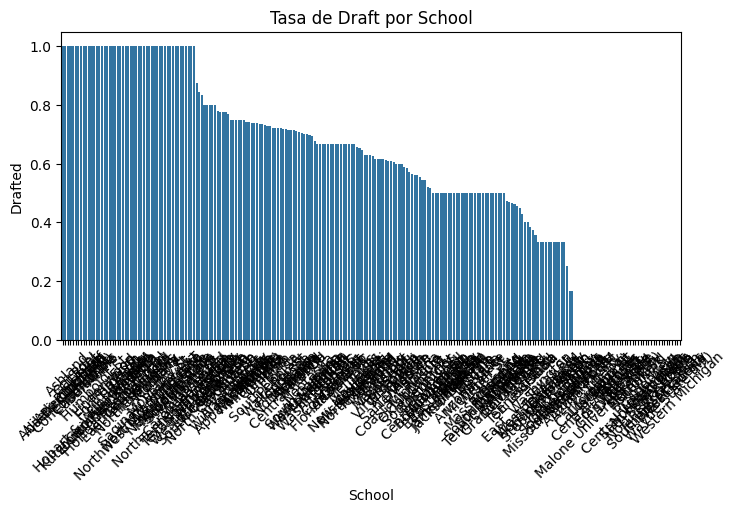

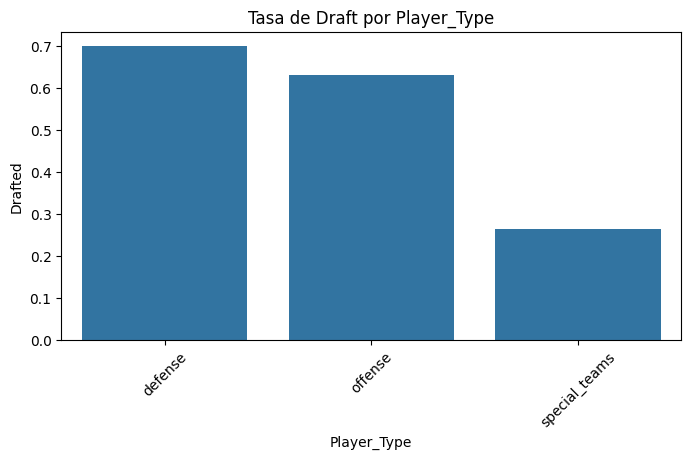

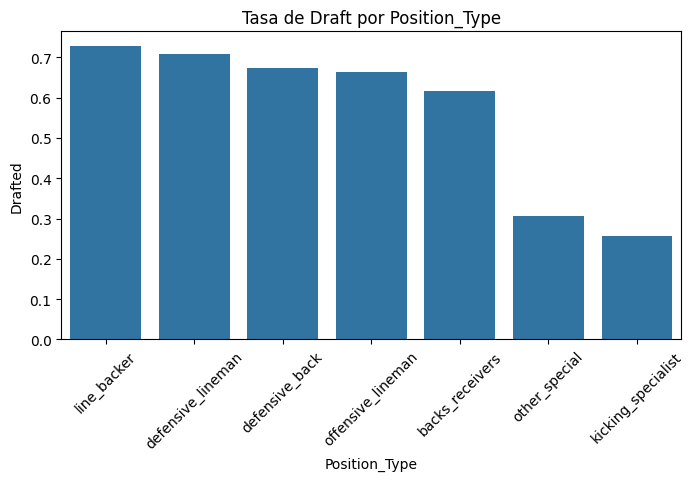

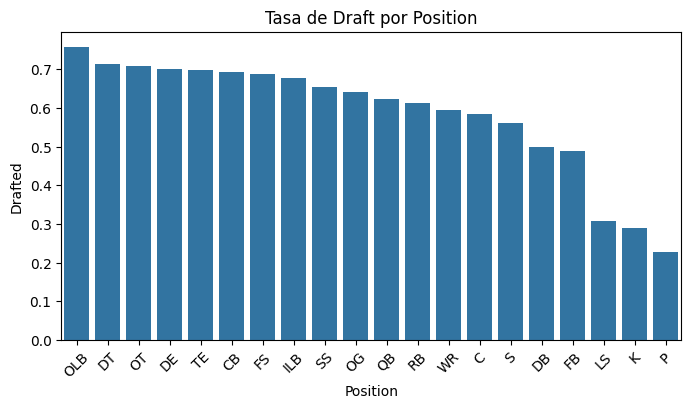

In [458]:
cat_cols = train.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(8,4))

    draft_rate = (
        train.groupby(col)['Drafted']
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    sns.barplot(data=draft_rate, x=col, y='Drafted')

    plt.title(f'Tasa de Draft por {col}')
    plt.xticks(rotation=45)
    plt.show()

In [459]:
school_stats = train.groupby('School').agg(
    Total_Jugadores=('Drafted', 'count'),
    Drafteados=('Drafted', 'sum'),
    Tasa_Draft=('Drafted', 'mean')
).reset_index()

print("Tasa de draft por escuela:")
print(school_stats.sort_values('Tasa_Draft', ascending=False))
print("\n")

Tasa de draft por escuela:
                School  Total_Jugadores  Drafteados  Tasa_Draft
0    Abilene Christian                3           3         1.0
3       Ala-Birmingham                2           2         1.0
16             Ashland                1           1         1.0
12      Ark-Pine Bluff                1           1         1.0
43      Concordia (MN)                1           1         1.0
..                 ...              ...         ...         ...
222   Wayne State (MI)                2           0         0.0
224       West Georgia                1           0         0.0
225       West Liberty                1           0         0.0
230   Western Michigan                1           0         0.0
234               Yale                2           0         0.0

[236 rows x 4 columns]




=== TOP 20 ESCUELAS CON MEJOR TASA DE DRAFT ===
                     School  Total_Jugadores  Drafteados  Tasa_Draft
0         Abilene Christian                3           3         1.0
3            Ala-Birmingham                2           2         1.0
16                  Ashland                1           1         1.0
12           Ark-Pine Bluff                1           1         1.0
43           Concordia (MN)                1           1         1.0
28                 Cal Poly                2           2         1.0
38                  Citadel                2           2         1.0
36                Charlotte                1           1         1.0
35              Chadron St.                1           1         1.0
53           East. Illinois                1           1         1.0
48                    Drake                1           1         1.0
46                 Delaware                1           1         1.0
79   Hobart & William Smith                1           

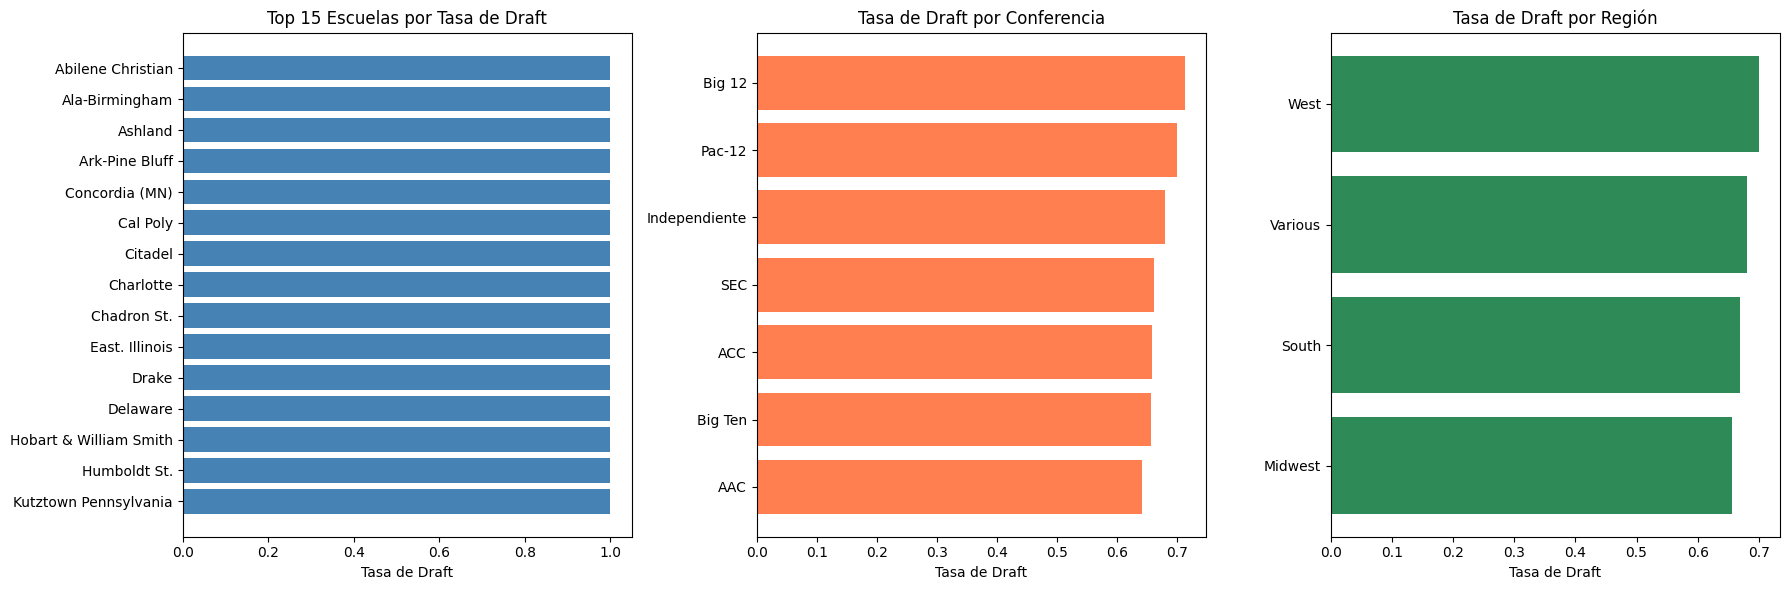


=== PRUEBA ESTADÍSTICA ===
ANOVA entre conferencias: F-statistic = 0.6103, p-value = 0.7223
❌ No hay diferencias estadísticamente significativas entre conferencias

=== ESCUELAS QUE MÁS SUPERAN EL PROMEDIO DE SU CONFERENCIA ===
           School Conference  Tasa_Draft  Conf_Avg  Por_Encima_Promedio
128          Navy        AAC    1.000000  0.641509             0.358491
145  Northwestern    Big Ten    0.846154  0.656716             0.189437
71   Georgia Tech        ACC    0.800000  0.658273             0.141727
68        Georgia        SEC    0.777778  0.661386             0.116392
163       Rutgers    Big Ten    0.750000  0.656716             0.093284
165           SMU        AAC    0.727273  0.641509             0.085763
207          UCLA     Pac-12    0.780488  0.699690             0.080797
58        Florida        SEC    0.740000  0.661386             0.078614
39        Clemson        ACC    0.736842  0.658273             0.078569
88           Iowa    Big Ten    0.723404  0.656716 

In [460]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# 1. ANÁLISIS POR ESCUELA (individual)
# ============================================
school_stats = train.groupby('School').agg(
    Total_Jugadores=('Drafted', 'count'),
    Drafteados=('Drafted', 'sum'),
    Tasa_Draft=('Drafted', 'mean')
).reset_index()

# Ordenar por tasa de draft
school_stats_sorted = school_stats.sort_values('Tasa_Draft', ascending=False)

print("=== TOP 20 ESCUELAS CON MEJOR TASA DE DRAFT ===")
print(school_stats_sorted.head(20))
print("\n")

print("=== TOP 20 ESCUELAS CON MÁS JUGADORES DRAFTEADOS ===")
print(school_stats.sort_values('Drafteados', ascending=False).head(20))
print("\n")

# ============================================
# 2. AGRUPAR POR CONFERENCIA (necesitas mapear)
# ============================================
# Crear diccionario de mapeo Escuela -> Conferencia
# (Ejemplo con algunas escuelas populares - DEBES COMPLETAR ESTO)

conference_map = {
    # SEC
    'Alabama': 'SEC',
    'Georgia': 'SEC',
    'LSU': 'SEC',
    'Florida': 'SEC',
    'Texas A&M': 'SEC',
    'Auburn': 'SEC',
    'Tennessee': 'SEC',
    'Ole Miss': 'SEC',
    'Mississippi State': 'SEC',
    'South Carolina': 'SEC',
    'Kentucky': 'SEC',
    'Missouri': 'SEC',
    'Arkansas': 'SEC',
    'Vanderbilt': 'SEC',

    # Big Ten
    'Ohio State': 'Big Ten',
    'Michigan': 'Big Ten',
    'Penn State': 'Big Ten',
    'Wisconsin': 'Big Ten',
    'Iowa': 'Big Ten',
    'Michigan State': 'Big Ten',
    'Nebraska': 'Big Ten',
    'Minnesota': 'Big Ten',
    'Maryland': 'Big Ten',
    'Purdue': 'Big Ten',
    'Illinois': 'Big Ten',
    'Indiana': 'Big Ten',
    'Rutgers': 'Big Ten',
    'Northwestern': 'Big Ten',

    # ACC
    'Clemson': 'ACC',
    'Florida State': 'ACC',
    'Miami': 'ACC',
    'North Carolina': 'ACC',
    'Virginia Tech': 'ACC',
    'Pittsburgh': 'ACC',
    'Duke': 'ACC',
    'Virginia': 'ACC',
    'NC State': 'ACC',
    'Louisville': 'ACC',
    'Boston College': 'ACC',
    'Wake Forest': 'ACC',
    'Syracuse': 'ACC',
    'Georgia Tech': 'ACC',

    # Big 12
    'Oklahoma': 'Big 12',
    'Texas': 'Big 12',
    'TCU': 'Big 12',
    'Oklahoma State': 'Big 12',
    'Baylor': 'Big 12',
    'Kansas State': 'Big 12',
    'Iowa State': 'Big 12',
    'West Virginia': 'Big 12',
    'Texas Tech': 'Big 12',
    'Kansas': 'Big 12',

    # Pac-12
    'USC': 'Pac-12',
    'Oregon': 'Pac-12',
    'Washington': 'Pac-12',
    'Utah': 'Pac-12',
    'UCLA': 'Pac-12',
    'Arizona State': 'Pac-12',
    'Stanford': 'Pac-12',
    'California': 'Pac-12',
    'Oregon State': 'Pac-12',
    'Colorado': 'Pac-12',
    'Arizona': 'Pac-12',
    'Washington State': 'Pac-12',

    # Independientes
    'Notre Dame': 'Independiente',
    'Liberty': 'Independiente',
    'New Mexico State': 'Independiente',
    'Connecticut': 'Independiente',

    # AAC (American Athletic)
    'Cincinnati': 'AAC',
    'Houston': 'AAC',
    'UCF': 'AAC',
    'Memphis': 'AAC',
    'SMU': 'AAC',
    'Navy': 'AAC',
}

# Aplicar mapeo (las escuelas no mapeadas quedarán como NaN)
train['Conference'] = train['School'].map(conference_map)

# Ver cuántas escuelas no tienen conferencia asignada
missing_conferences = train[train['Conference'].isna()]['School'].unique()
print(f"Escuelas sin conferencia asignada: {len(missing_conferences)}")
print("Ejemplos de primeras 10 escuelas sin mapear:")
print(missing_conferences[:10])
print("\n")

# Calcular estadísticas por conferencia
conf_stats = train.groupby('Conference').agg(
    Total_Jugadores=('Drafted', 'count'),
    Drafteados=('Drafted', 'sum'),
    Tasa_Draft=('Drafted', 'mean')
).reset_index()

# Eliminar conferencias NaN (las que no mapeamos)
conf_stats = conf_stats.dropna()

print("=== TASA DE DRAFT POR CONFERENCIA ===")
print(conf_stats.sort_values('Tasa_Draft', ascending=False))
print("\n")

# ============================================
# 3. AGRUPAR POR REGIÓN
# ============================================
# Crear mapeo de conferencia a región
region_map = {
    'SEC': 'South',
    'ACC': 'South',
    'Big 12': 'South',
    'Big Ten': 'Midwest',
    'Pac-12': 'West',
    'AAC': 'South',
    'Independiente': 'Various'
}

train['Region'] = train['Conference'].map(region_map)

# Calcular estadísticas por región
region_stats = train.groupby('Region').agg(
    Total_Jugadores=('Drafted', 'count'),
    Drafteados=('Drafted', 'sum'),
    Tasa_Draft=('Drafted', 'mean')
).reset_index()

region_stats = region_stats.dropna()

print("=== TASA DE DRAFT POR REGIÓN ===")
print(region_stats.sort_values('Tasa_Draft', ascending=False))
print("\n")

# ============================================
# 4. VISUALIZACIÓN DE RESULTADOS
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico 1: Top 15 escuelas
top_schools = school_stats_sorted.head(15)
axes[0].barh(range(len(top_schools)), top_schools['Tasa_Draft'], color='steelblue')
axes[0].set_yticks(range(len(top_schools)))
axes[0].set_yticklabels(top_schools['School'])
axes[0].set_xlabel('Tasa de Draft')
axes[0].set_title('Top 15 Escuelas por Tasa de Draft')
axes[0].invert_yaxis()

# Gráfico 2: Por conferencia
conf_sorted = conf_stats.sort_values('Tasa_Draft', ascending=True)
axes[1].barh(conf_sorted['Conference'], conf_sorted['Tasa_Draft'], color='coral')
axes[1].set_xlabel('Tasa de Draft')
axes[1].set_title('Tasa de Draft por Conferencia')

# Gráfico 3: Por región
region_sorted = region_stats.sort_values('Tasa_Draft', ascending=True)
axes[2].barh(region_sorted['Region'], region_sorted['Tasa_Draft'], color='seagreen')
axes[2].set_xlabel('Tasa de Draft')
axes[2].set_title('Tasa de Draft por Región')

plt.tight_layout()
plt.show()

# ============================================
# 5. ANÁLISIS ESTADÍSTICO
# ============================================
from scipy.stats import f_oneway

# Preparar datos para ANOVA (comparar conferencias)
conference_groups = [train[train['Conference'] == conf]['Drafted'].values
                     for conf in conf_stats['Conference'].values]

# Eliminar grupos vacíos
conference_groups = [group for group in conference_groups if len(group) > 0]

if len(conference_groups) > 1:
    f_stat, p_value = f_oneway(*conference_groups)
    print("\n=== PRUEBA ESTADÍSTICA ===")
    print(f"ANOVA entre conferencias: F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")
    if p_value < 0.05:
        print("✅ Diferencias significativas encontradas entre conferencias")
    else:
        print("❌ No hay diferencias estadísticamente significativas entre conferencias")

# ============================================
# 6. ESCUELAS QUE DESTACAN EN SU CONFERENCIA
# ============================================
# Calcular promedio de conferencia
conf_avg = train.groupby('Conference')['Drafted'].mean()

# Agregar promedio de conferencia a cada escuela
school_stats_with_conf = school_stats.copy()
school_stats_with_conf['Conference'] = school_stats_with_conf['School'].map(conference_map)
school_stats_with_conf = school_stats_with_conf.dropna()
school_stats_with_conf['Conf_Avg'] = school_stats_with_conf['Conference'].map(conf_avg)
school_stats_with_conf['Por_Encima_Promedio'] = (school_stats_with_conf['Tasa_Draft'] -
                                                  school_stats_with_conf['Conf_Avg'])

# Escuelas que superan más a su conferencia
print("\n=== ESCUELAS QUE MÁS SUPERAN EL PROMEDIO DE SU CONFERENCIA ===")
top_outperformers = school_stats_with_conf.nlargest(10, 'Por_Encima_Promedio')
print(top_outperformers[['School', 'Conference', 'Tasa_Draft', 'Conf_Avg', 'Por_Encima_Promedio']])

In [461]:
top_performers = pd.DataFrame({
    'School': ['Navy', 'Northwestern', 'Georgia Tech', 'Georgia', 'Rutgers',
               'SMU', 'UCLA', 'Florida', 'Clemson', 'Iowa'],
    'Conference': ['AAC', 'Big Ten', 'ACC', 'SEC', 'Big Ten',
                   'AAC', 'Pac-12', 'SEC', 'ACC', 'Big Ten'],
    'Tasa_Draft': [1.000, 0.846, 0.800, 0.778, 0.750,
                   0.727, 0.780, 0.740, 0.737, 0.723],
    'Conf_Avg': [0.642, 0.657, 0.658, 0.661, 0.657,
                 0.642, 0.700, 0.661, 0.658, 0.657],
    'Por_Encima': [0.358, 0.189, 0.142, 0.116, 0.093,
                   0.086, 0.081, 0.079, 0.079, 0.067]
})

print("=== ANÁLISIS DE ESCUELAS QUE MÁS SUPERAN A SU CONFERENCIA ===\n")

# Agrupar por conferencia
print("Por conferencia:")
print(top_performers.groupby('Conference')['School'].count())
print("\n")

# Escuelas con tasa perfecta
perfect_schools = top_performers[top_performers['Tasa_Draft'] == 1.0]
print(f"Escuelas con tasa de draft perfecta (100%): {perfect_schools['School'].values}")
print("⚠️ Nota: Navy con 100% sugiere pocos jugadores en el dataset (probablemente 1 o 2)")
print("\n")

=== ANÁLISIS DE ESCUELAS QUE MÁS SUPERAN A SU CONFERENCIA ===

Por conferencia:
Conference
AAC        2
ACC        2
Big Ten    3
Pac-12     1
SEC        2
Name: School, dtype: int64


Escuelas con tasa de draft perfecta (100%): ['Navy']
⚠️ Nota: Navy con 100% sugiere pocos jugadores en el dataset (probablemente 1 o 2)




In [462]:
school_sample_sizes = train.groupby('School').size().reset_index(name='Jugadores')
school_sample_sizes = school_sample_sizes[school_sample_sizes['School'].isin(top_performers['School'])]

print("=== TAMAÑO DE MUESTRA DE ESCUELAS DESTACADAS ===")
for _, row in school_sample_sizes.iterrows():
    tasa = top_performers[top_performers['School'] == row['School']]['Tasa_Draft'].values[0]
    print(f"{row['School']:15s} - {row['Jugadores']:3d} jugadores - Tasa: {tasa:.1%}")

# ============================================
# 3. VERIFICAR SIGNIFICANCIA DE DIFERENCIAS (TEST DE PROPORCIONES)
# ============================================
from statsmodels.stats.proportion import proportions_ztest

print("\n=== PRUEBA DE SIGNIFICANCIA PARA CADA ESCUELA VS SU CONFERENCIA ===")

for _, row in top_performers.iterrows():
    school = row['School']
    conf = row['Conference']
    tasa_school = row['Tasa_Draft']
    tasa_conf = row['Conf_Avg']

    # Obtener datos reales (necesitas train)
    school_data = train[train['School'] == school]
    conf_data = train[train['Conference'] == conf]

    n_school = len(school_data)
    n_conf = len(conf_data)
    drafted_school = school_data['Drafted'].sum()
    drafted_conf = conf_data['Drafted'].sum()

    # Prueba de proporciones (escuela vs conferencia)
    count = [drafted_school, drafted_conf - drafted_school]
    nobs = [n_school, n_conf - n_school]

    try:
        z_stat, p_val = proportions_ztest(count, nobs, alternative='larger')
        if p_val < 0.05:
            print(f"✅ {school:15s} - Significativamente MEJOR que {conf} (p={p_val:.4f})")
        else:
            print(f"⚠️ {school:15s} - No significativamente mejor que {conf} (p={p_val:.4f})")
    except:
        print(f"❌ {school:15s} - No se pudo calcular (muestra pequeña?)")

=== TAMAÑO DE MUESTRA DE ESCUELAS DESTACADAS ===
Clemson         -  57 jugadores - Tasa: 73.7%
Florida         -  50 jugadores - Tasa: 74.0%
Georgia         -  54 jugadores - Tasa: 77.8%
Georgia Tech    -  15 jugadores - Tasa: 80.0%
Iowa            -  47 jugadores - Tasa: 72.3%
Navy            -   1 jugadores - Tasa: 100.0%
Northwestern    -  13 jugadores - Tasa: 84.6%
Rutgers         -  16 jugadores - Tasa: 75.0%
SMU             -  11 jugadores - Tasa: 72.7%
UCLA            -  41 jugadores - Tasa: 78.0%

=== PRUEBA DE SIGNIFICANCIA PARA CADA ESCUELA VS SU CONFERENCIA ===
⚠️ Navy            - No significativamente mejor que AAC (p=0.2252)
⚠️ Northwestern    - No significativamente mejor que Big Ten (p=0.0701)
⚠️ Georgia Tech    - No significativamente mejor que ACC (p=0.1170)
✅ Georgia         - Significativamente MEJOR que SEC (p=0.0279)
⚠️ Rutgers         - No significativamente mejor que Big Ten (p=0.2088)
⚠️ SMU             - No significativamente mejor que AAC (p=0.2526)
⚠️ UCLA  

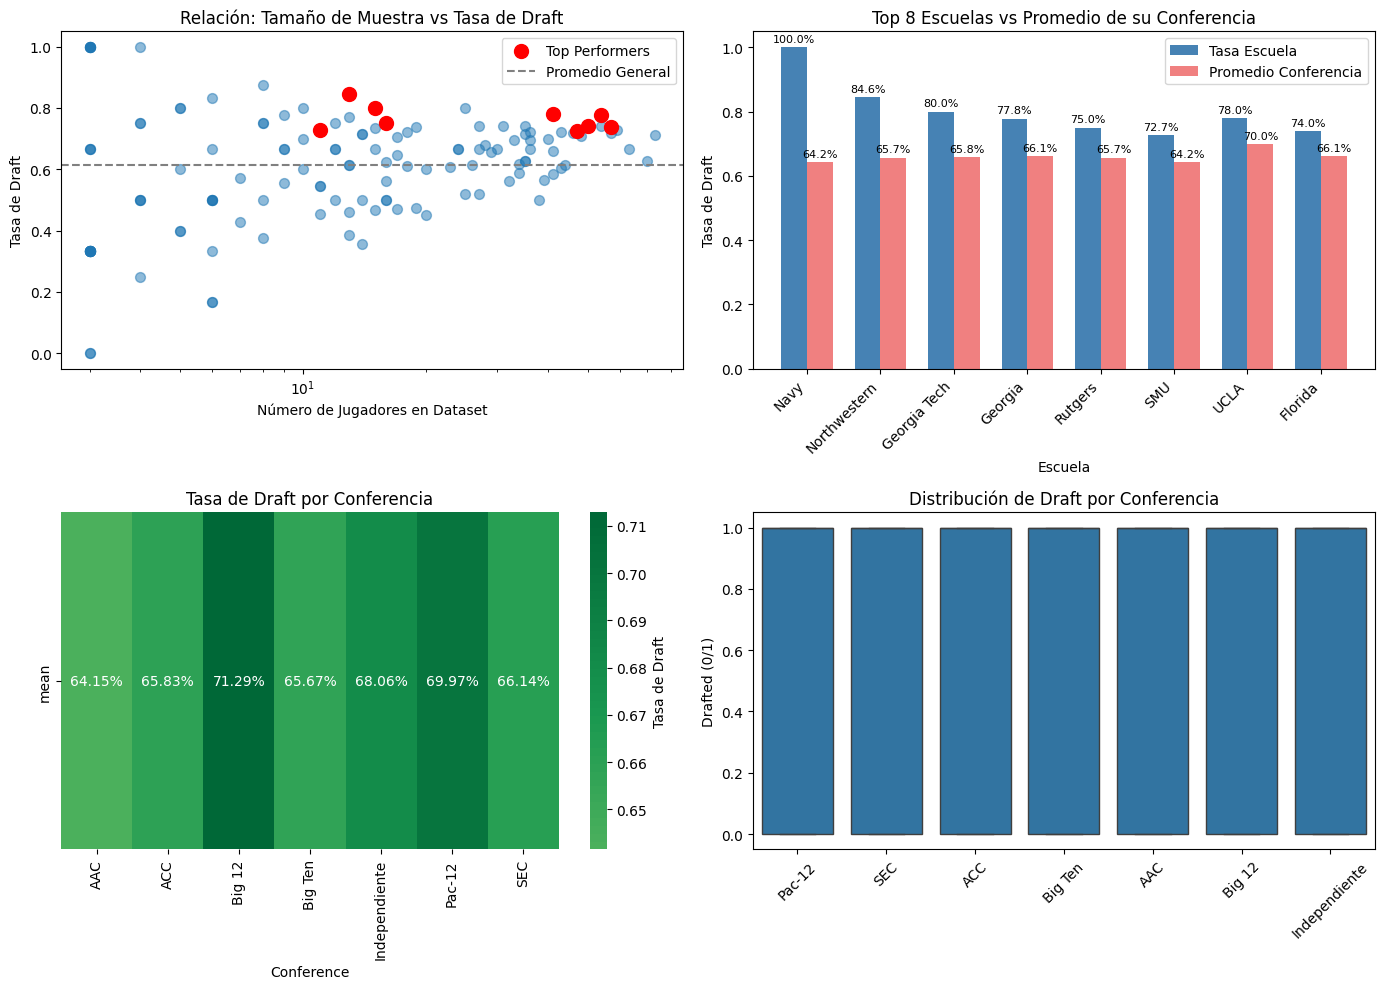

In [463]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Top performers vs promedio conferencia
ax1 = axes[0, 1]
schools = top_performers['School'][:8]
x = np.arange(len(schools))
width = 0.35

bars1 = ax1.bar(x - width/2, top_performers['Tasa_Draft'][:8], width, label='Tasa Escuela', color='steelblue')
bars2 = ax1.bar(x + width/2, top_performers['Conf_Avg'][:8], width, label='Promedio Conferencia', color='lightcoral')

ax1.set_xlabel('Escuela')
ax1.set_ylabel('Tasa de Draft')
ax1.set_title('Top 8 Escuelas vs Promedio de su Conferencia')
ax1.set_xticks(x)
ax1.set_xticklabels(schools, rotation=45, ha='right')
ax1.legend()
ax1.set_ylim(0, 1.05)

# Añadir etiquetas de valor
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.1%}', ha='center', va='bottom', fontsize=8)

# Gráfico 2: Heatmap de conferencias
ax2 = axes[1, 0]
conf_matrix = train.groupby('Conference')['Drafted'].agg(['mean', 'count']).reset_index()
conf_matrix = conf_matrix[conf_matrix['count'] > 10]
pivot_data = conf_matrix.set_index('Conference')[['mean']]
sns.heatmap(pivot_data.T, annot=True, fmt='.2%', cmap='RdYlGn', center=0.5,
            cbar_kws={'label': 'Tasa de Draft'}, ax=ax2)
ax2.set_title('Tasa de Draft por Conferencia')
ax2.set_ylabel('')

# Gráfico 3: Distribución de tasas por conferencia
ax3 = axes[1, 1]
conf_data_to_plot = train[train['Conference'].isin(conf_matrix['Conference'].values)]
sns.boxplot(data=conf_data_to_plot, x='Conference', y='Drafted', ax=ax3)
ax3.set_title('Distribución de Draft por Conferencia')
ax3.set_ylabel('Drafted (0/1)')
ax3.set_xlabel('')
ax3.tick_params(axis='x', rotation=45)

# Gráfico 4: Tamaño de muestra vs tasa de draft
ax4 = axes[0, 0]
school_all_stats = train.groupby('School').agg(
    Jugadores=('Drafted', 'count'),
    Tasa=('Drafted', 'mean')
).reset_index()
school_all_stats = school_all_stats[school_all_stats['Jugadores'] >= 3]

ax4.scatter(school_all_stats['Jugadores'], school_all_stats['Tasa'], alpha=0.5, s=50)
top_schools_data = school_all_stats[school_all_stats['School'].isin(top_performers['School'])]
ax4.scatter(top_schools_data['Jugadores'], top_schools_data['Tasa'],
           color='red', s=100, label='Top Performers', zorder=5)
ax4.set_xlabel('Número de Jugadores en Dataset')
ax4.set_ylabel('Tasa de Draft')
ax4.set_title('Relación: Tamaño de Muestra vs Tasa de Draft')
ax4.axhline(y=school_all_stats['Tasa'].mean(), color='gray', linestyle='--', label='Promedio General')
ax4.legend()
ax4.set_xscale('log')

plt.tight_layout()
plt.show()



In [464]:
for col in ['Bench_Press_Reps', 'Vertical_Jump','Sprint_40yd','Broad_Jump','Agility_3cone','Shuttle'	]:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = train[(train[col] < lower) | (train[col] > upper)]

    print(f"{col}: {len(outliers)} valores atípicos")

Bench_Press_Reps: 15 valores atípicos
Vertical_Jump: 11 valores atípicos
Sprint_40yd: 13 valores atípicos
Broad_Jump: 36 valores atípicos
Agility_3cone: 13 valores atípicos
Shuttle: 17 valores atípicos


In [465]:
train[col] = train[col].clip(lower=lower, upper=upper)

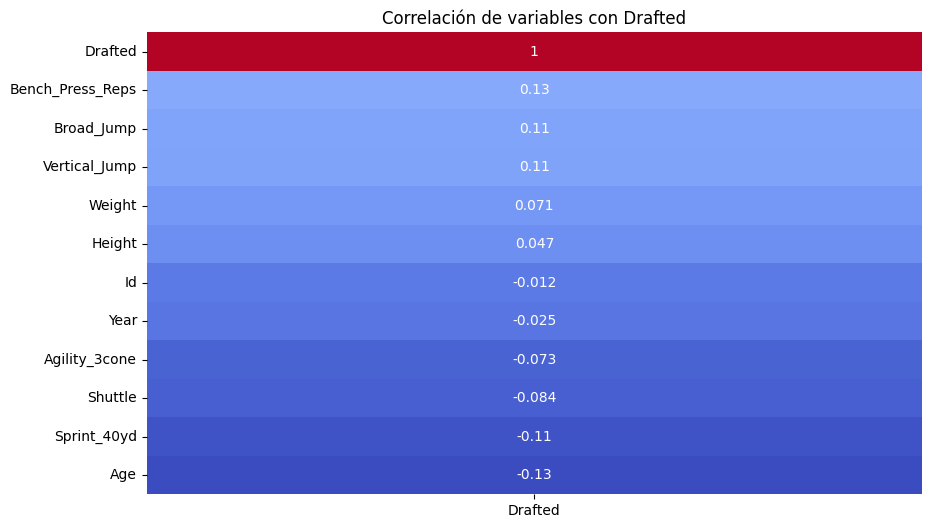

In [466]:
numeric_train = train.select_dtypes(include=np.number)
corr = numeric_train.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr[['Drafted']].sort_values(by='Drafted', ascending=False),
            annot=True, cmap="coolwarm", cbar=False)
plt.title("Correlación de variables con Drafted")
plt.show()

## 4. Preprocesamiento

Aquí, realizaremos el preprocesamiento y crearemos nuevas características basadas en lo que hemos aprendido en la visualización y el análisis anteriores. Realizaremos **imputación de valores faltantes** y **codificación**.

### 4.1 Eliminación de Columnas

En este cuaderno, excluiremos las características categóricas con un número relativamente grande de niveles únicos. Específicamente, eliminaremos la columna **School** (**236** valores únicos). *(Nota: School aún puede influir en Drafted; si desea explorar más a fondo, intente incluirla como una característica.)* También eliminaremos la columna **Id**, ya que se espera que no esté relacionada con si un jugador es seleccionado en el draft.

In [467]:
# Drop unused columns
train = train.drop(columns=["Id", "School"])
test = test.drop(columns=["Id","School"])

### 4.2 Manejo de Valores Faltantes

Hay valores faltantes en **Age**, **Sprint_40yd**, **Vertical_Jump**, **Bench_Press_Reps**, **Broad_Jump**, **Agility_3cone** y **Shuttle**. En este cuaderno, imputaremos estos valores faltantes utilizando la media de cada columna.

In [468]:
# Columns to impute with the mean
cols_to_fill = ['Age', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
                'Broad_Jump', 'Agility_3cone', 'Shuttle']

# Impute both train and test using the means computed from the training data
for col in cols_to_fill:
    mean_value = train[col].mean()
    train[col] = train[col].fillna(mean_value)
    test[col] = test[col].fillna(mean_value)

Comprobemos si hay valores faltantes.

In [469]:
train.isnull().sum()

,0
Year,0
Age,0
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0
Agility_3cone,0
Shuttle,0


In [470]:
test.isnull().sum()

,0
Year,0
Age,0
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0
Agility_3cone,0
Shuttle,0


Ahora, los valores faltantes en **train** y **test** han sido manejados.

### 4.3 Manejo de Datos Categóricos

A continuación, convertiremos las características categóricas en valores numéricos para que puedan usarse como entradas del modelo. La mayoría de los modelos de aprendizaje automático solo pueden aceptar datos numéricos.

Aquí, utilizaremos una técnica llamada **codificación de etiquetas**.

In [471]:
# Label-encode the categorical features
label_encoders = {}
for c in ["Player_Type", "Position_Type", "Position"]:
    label_encoders[c] = LabelEncoder()
    train[c] = label_encoders[c].fit_transform(train[c].astype(str))
    test[c] = label_encoders[c].transform(test[c].astype(str))

### [Próximos Pasos]

El preprocesamiento aquí es intencionalmente mínimo. Es probable que pueda mejorar la puntuación cambiando la forma en que se preparan las características:

- **Imputación**: pruebe la mediana, una media por grupo (por ejemplo, la media por **Position**) o un imputador basado en modelos como `KNNImputer`.
- **Codificación**: pruebe **Codificación One-Hot**, **Codificación de Objetivo (Media)** o **Codificación de Frecuencia** en lugar de codificación de etiquetas.
- **School**: en lugar de eliminarla, intente codificarla (por ejemplo, codificación de objetivo o codificación de frecuencia).
- Agregue un **indicador de valor faltante** (una columna 0/1 que registre si el valor original estaba faltante).

In [472]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

# Redefine numeric_cols to reflect current state of train/test DataFrames
# Exclude 'Drafted' from train as it's the target
current_numeric_cols_train = train.select_dtypes(include=np.number).columns.drop('Drafted')
current_numeric_cols_test = test.select_dtypes(include=np.number).columns

train[current_numeric_cols_train] = imputer.fit_transform(train[current_numeric_cols_train])
test[current_numeric_cols_test] = imputer.transform(test[current_numeric_cols_test])

In [473]:
missing_cols = [
    'Age',
    'Sprint_40yd',
    'Vertical_Jump',
    'Bench_Press_Reps',
    'Broad_Jump',
    'Agility_3cone',
    'Shuttle'
]

for col in missing_cols:
    train[f'{col}_missing'] = train[col].isna().astype(int)
    test[f'{col}_missing'] = test[col].isna().astype(int)

print("Missing indicator columns created successfully for train and test.")

Missing indicator columns created successfully for train and test.


In [474]:
# Calculate position-specific statistics from training data to avoid data leakage
position_stats_fe = train.groupby('Position').agg(
    position_draft_rate=('Drafted', 'mean'),
    position_avg_weight=('Weight', 'mean'),
    position_avg_height=('Height', 'mean')
).reset_index()

# Merge these new features into both train and test dataframes
train = train.merge(position_stats_fe, on='Position', how='left')
test = test.merge(position_stats_fe, on='Position', how='left')

print("Created new features: 'position_draft_rate', 'position_avg_weight', 'position_avg_height'.")
print(f"Train shape after adding position features: {train.shape}")
print(f"Test shape after adding position features: {test.shape}")

Created new features: 'position_draft_rate', 'position_avg_weight', 'position_avg_height'.
Train shape after adding position features: (2781, 26)
Test shape after adding position features: (696, 23)


Analiza las variables numéricas del conjunto de datos relacionadas con el rendimiento atlético (Vertical_Jump, Broad_Jump, Sprint_40yd, Weight, Height, etc.) y propón nuevas características que representen mejor la capacidad física global de un atleta.

En particular, crea variables compuestas que combinen explosividad, velocidad, fuerza y tamaño corporal. Evita simplemente sumar variables con escalas diferentes; en su lugar, considera normalización, estandarización o relaciones matemáticamente coherentes.

Genera características como:

Un índice de explosividad basado en Vertical_Jump y Broad_Jump.
Un índice de velocidad que tenga en cuenta el peso corporal y el tiempo en Sprint_40yd.
Un índice global de atletismo que combine velocidad y explosividad.
Métricas específicas por posición si pueden aportar información adicional.

Para cada característica propuesta:

Explica la lógica deportiva detrás de ella.
Indica por qué podría ayudar a predecir la variable objetivo Drafted.
Proporciona el código completo en Python/Pandas para crearla en train y test.
Evita cualquier fuga de información (data leakage).
Mantén las variables originales además de las nuevas características.

Finalmente, ordena las nuevas variables según el impacto esperado sobre una métrica AUC en un problema de clasificación binaria.

In [475]:
train['Athletic_Score'] = (
    train['Vertical_Jump']
    + train['Broad_Jump']
    - train['Sprint_40yd']
)

test['Athletic_Score'] = (
    test['Vertical_Jump']
    + test['Broad_Jump']
    - test['Sprint_40yd']
)

print("Athletic_Score feature created in train and test DataFrames.")

Athletic_Score feature created in train and test DataFrames.


### Explorando diferentes codificaciones para 'School'

La `School_TE` (Target Encoding) puede ser propensa a overfitting si hay muchas categorías con pocas muestras, o si el esquema de validación cruzada no se maneja cuidadosamente. Para abordar esto, exploraremos `Frequency Encoding` y una combinación de ambas.

**Frequency Encoding** reemplaza cada categoría con la frecuencia o el recuento de sus ocurrencias en el conjunto de datos. Esto puede ser útil para categorías con muchos niveles, ya que reduce la dimensionalidad y puede capturar información sobre la prevalencia de una categoría.

In [476]:
for col in cols_to_fill:
    train[f'{col}_missing'] = train[col].isna().astype(int)
    test[f'{col}_missing'] = test[col].isna().astype(int)

In [477]:
from sklearn.impute import KNNImputer

current_numeric_cols_train = train.select_dtypes(include=np.number).columns.drop('Drafted')
current_numeric_cols_test = test.select_dtypes(include=np.number).columns

# Crear imputador
knn_imputer = KNNImputer(n_neighbors=5)

# Ajustar en train y transformar
train[current_numeric_cols_train] = knn_imputer.fit_transform(
    train[current_numeric_cols_train]
)

# Transformar test usando la información aprendida de train
test[current_numeric_cols_test] = knn_imputer.transform(
    test[current_numeric_cols_test]
)

In [478]:
# Opcional: Asignar 'Otras' a las escuelas no mapeadas
train['Conference'] = train['Conference'].fillna('Otras')


In [479]:
from sklearn.preprocessing import OneHotEncoder

# Usar OneHotEncoder de sklearn (mejor para pipelines)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
conference_encoded = encoder.fit_transform(train[['Conference']])

# Crear DataFrame con nombres de columnas
conference_encoded_df = pd.DataFrame(
    conference_encoded,
    columns=encoder.get_feature_names_out(['Conference']),
    index=train.index
)

# Unir
train_encoded_sklearn = pd.concat([train, conference_encoded_df], axis=1)

print("\n=== ONE-HOT ENCODING CON SKLEARN ===")
print(f"Columnas creadas: {conference_encoded_df.columns.tolist()}")


=== ONE-HOT ENCODING CON SKLEARN ===
Columnas creadas: ['Conference_AAC', 'Conference_ACC', 'Conference_Big 12', 'Conference_Big Ten', 'Conference_Independiente', 'Conference_Otras', 'Conference_Pac-12', 'Conference_SEC']


In [480]:
train_fe_with_te['School_Combined_TE_FE'] = train_fe_with_te['School_TE'] * train_fe_with_te['School_FE']
test_fe_with_te['School_Combined_TE_FE'] = test_fe_with_te['School_TE'] * test_fe_with_te['School_FE']

print("Created 'School_Combined_TE_FE' feature by multiplying 'School_TE' and 'School_FE'.")

Created 'School_Combined_TE_FE' feature by multiplying 'School_TE' and 'School_FE'.


## 5. Modelo de Línea Base

Ahora que los datos han sido preparados, los utilizaremos como entrada para construir un **modelo de línea base**. Un modelo de línea base es un modelo de aprendizaje automático inicial simple que sirve como punto de partida.

En este cuaderno, utilizaremos un modelo de **Bosques Aleatorios**, que es un método basado en árboles que realiza predicciones combinando muchos **árboles de decisión**.

Un árbol de decisión es un modelo intuitivo que divide repetidamente los datos utilizando preguntas simples de "sí/no". Por ejemplo: "¿Es el jugador más alto que 170 cm?" o "¿Es el jugador un pateador?". Al seguir estas condiciones paso a paso, el modelo llega a una predicción final.

Sin embargo, el uso de un solo árbol de decisión a menudo conduce a un modelo que se ajusta demasiado a los datos de entrenamiento y no se generaliza bien a datos nuevos; esto se denomina **sobreajuste**. Los Bosques Aleatorios abordan esto entrenando docenas (o incluso cientos) de árboles de decisión, cada uno en subconjuntos ligeramente diferentes de los datos y las características. Luego combina sus predicciones (típicamente promediando), lo que resulta en un modelo más estable y robusto.

Para evaluar el rendimiento del modelo, utilizaremos la **validación cruzada**. Este método divide el conjunto de datos en varios grupos (folds) y repite el entrenamiento y la evaluación varias veces.

En este cuaderno, utilizamos **validación cruzada de 5 folds**: los datos se dividen en cinco folds, y cada vez usamos un fold para validación y los cuatro folds restantes para entrenamiento. Repetimos este proceso cinco veces y tomamos la puntuación promedio como una estimación del rendimiento del modelo. La validación cruzada es útil porque proporciona una evaluación más confiable que una única división de entrenamiento/validación.

In [481]:
# Split into features and target
# Exclude 'Conference' and 'Region' columns as they contain non-numeric data not yet encoded for the model
X = train.drop(columns=["Drafted", "Conference", "Region"])
y = train["Drafted"]

# Set up the model and cross-validation
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=2025
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store scores
auc_scores = []

# Train and evaluate using Startified K-Fold cross-validation
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # Train the model
    model.fit(X_train, y_train)

    # Predict and score
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

# Print mean AUC
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))

Fold 1
  AUC: 0.7737
Fold 2
  AUC: 0.8357
Fold 3
  AUC: 0.8332
Fold 4
  AUC: 0.7694
Fold 5
  AUC: 0.8148

Average Validation AUC: 0.8054


Este modelo logró una puntuación AUC de **0.8115**.

### [Próximos Pasos]

La línea base utiliza un Bosque Aleatorio predeterminado. Formas comunes de mejorar a partir de aquí:

- Pruebe otros modelos: **Regresión Logística**, **LightGBM**, **XGBoost** o **CatBoost**.
- Ajuste los hiperparámetros como `n_estimators`, `max_depth` y `min_samples_leaf`. Comience con una cuadrícula pequeña y amplíela una vez que vea lo que ayuda.
- Compare algunos valores de `random_state` o cambie el número de folds (`n_splits`) para verificar que la puntuación sea estable.

In [482]:
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd
!pip install catboost
import catboost as cb # Import CatBoost

# Assuming X and y are already defined from the previous model evaluation (cell bn1PBKPpQjVC)
# X = train.drop(columns=["Drafted", "Conference", "Region"])
# y = train["Drafted"]

# Function to train and evaluate a model
def train_evaluate_model(model, X, y, skf, model_name):
    auc_scores = []
    print(f"\nTraining and evaluating {model_name} model...")
    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
        # Ensure consistent column order for X_train and X_valid
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model.fit(X_train, y_train)
        y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
        auc = roc_auc_score(y_valid, y_valid_pred_proba)
        auc_scores.append(auc)
        print(f"  Fold {fold + 1} AUC: {round(auc, 4)}")

    mean_auc = np.mean(auc_scores)
    print(f"Average Validation AUC for {model_name}: {round(mean_auc, 4)}")
    return mean_auc


# 1. Logistic Regression
print("\n--- Evaluating Logistic Regression ---")
logistic_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
# Re-using the skf (StratifiedKFold) from previous cells
log_reg_auc = train_evaluate_model(logistic_model, X, y, skf, "Logistic Regression")

# 2. LightGBM Classifier
print("\n--- Evaluating LightGBM Classifier ---")
lgbm_model = lgb.LGBMClassifier(objective='binary', random_state=42)
lgbm_auc = train_evaluate_model(lgbm_model, X, y, skf, "LightGBM")

# 3. CatBoost Classifier
print("\n--- Evaluating CatBoost Classifier ---")
cat_model = cb.CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=0,
    random_seed=42 # Add random_seed for reproducibility
)
cat_auc = train_evaluate_model(cat_model, X, y, skf, "CatBoost")

# Compare with previous baseline (from cell bn1PBKPpQjVC)
baseline_rf_auc = 0.8128 # Replace with the actual baseline AUC from RandomForest if it changed

print("\n--- Model Performance Comparison ---")
print(f"Baseline RandomForest AUC: {baseline_rf_auc}")
print(f"Logistic Regression AUC: {round(log_reg_auc, 4)}")
print(f"LightGBM AUC: {round(lgbm_auc, 4)}")
print(f"CatBoost AUC: {round(cat_auc, 4)}")


--- Evaluating Logistic Regression ---

Training and evaluating Logistic Regression model...
  Fold 1 AUC: 0.6525
  Fold 2 AUC: 0.7445
  Fold 3 AUC: 0.7542
  Fold 4 AUC: 0.6842
  Fold 5 AUC: 0.6563
Average Validation AUC for Logistic Regression: 0.6983

--- Evaluating LightGBM Classifier ---

Training and evaluating LightGBM model...
[LightGBM] [Info] Number of positive: 1442, number of negative: 782
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000174 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1086
[LightGBM] [Info] Number of data points in the train set: 2224, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.648381 -> initscore=0.611932
[LightGBM] [Info] Start training from score 0.611932
  Fold 1 AUC: 0.7937
[LightGBM] [Info] Number of positive: 1442, number of negative: 783
[LightGBM] [Info] Auto

In [ ]:
from sklearn.model_selection import GridSearchCV

print("\n--- Ajuste de Hiperparámetros para RandomForestClassifier ---")

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 150], # Number of trees in the forest
    'max_depth': [3, 5, 7],      # Maximum depth of the tree
    'min_samples_leaf': [1, 5, 10] # Minimum number of samples required to be at a leaf node
}

# Re-initialize the RandomForestClassifier (using default random_state for reproducibility)
model_rf = RandomForestClassifier(random_state=2025)

# Setup GridSearchCV
# We'll use the 'skf' (StratifiedKFold) defined previously for cross-validation
# scoring='roc_auc' will optimize for AUC
grid_search = GridSearchCV(estimator=model_rf,
                           param_grid=param_grid,
                           scoring='roc_auc',
                           cv=skf, # Use the same StratifiedKFold as before
                           n_jobs=-1, # Use all available cores
                           verbose=1)

# Fit GridSearchCV to the data
# X and y are assumed to be prepared from previous steps (including BMI, Weight_per_40yd, position means)
# X = train.drop(columns=["Drafted", "Conference", "Region"])
# y = train["Drafted"]

grid_search.fit(X, y)

print("\nMejores parámetros encontrados:", grid_search.best_params_)
print("Mejor AUC de validación (usando los mejores parámetros):", round(grid_search.best_score_, 4))

# You can now use the best estimator found by GridSearchCV
best_rf_model = grid_search.best_estimator_

# Optional: Re-evaluate the best model with cross-validation to confirm performance
# You can use the train_evaluate_model function defined previously if you wish
# print("\nRe-evaluando el mejor modelo encontrado por GridSearchCV...")
# best_model_auc = train_evaluate_model(best_rf_model, X, y, skf, "RandomForest (Tuned)")



--- Ajuste de Hiperparámetros para RandomForestClassifier ---
Fitting 5 folds for each of 27 candidates, totalling 135 fits


In [ ]:
print("\n--- Verificando la estabilidad del AUC con diferentes random_state ---")

# Define una lista de random_state para probar
random_states_to_test = [0, 42, 100, 2025, 5000]

# Usa el modelo RandomForestClassifier con los parámetros del baseline
model_rf_stability = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=2025 # El random_state del modelo se mantiene fijo para esta prueba
)

auc_results_random_state = {}

for r_state in random_states_to_test:
    print(f"\nEvaluando con StratifiedKFold random_state={r_state}, n_splits=5")
    skf_r_state = StratifiedKFold(n_splits=5, shuffle=True, random_state=r_state)
    avg_auc = train_evaluate_model(model_rf_stability, X, y, skf_r_state, f"RandomForest (SKF_r_state={r_state})")
    auc_results_random_state[r_state] = avg_auc

print("\n--- Resumen de AUC con diferentes random_state ---")
for r_state, auc_val in auc_results_random_state.items():
    print(f"Random State {r_state}: {round(auc_val, 4)}")

print("\n--- Verificando la estabilidad del AUC con diferente n_splits ---")

# Define un número diferente de folds para probar
n_splits_to_test = [3, 10] # Ya probamos con 5, ahora probamos con 3 y 10

# Usa el mismo modelo RandomForestClassifier y un random_state fijo para SKF
model_rf_nsplits = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=2025
)

auc_results_nsplits = {}

for n_splits_val in n_splits_to_test:
    print(f"\nEvaluando con StratifiedKFold n_splits={n_splits_val}, random_state=42")
    skf_nsplits = StratifiedKFold(n_splits=n_splits_val, shuffle=True, random_state=42)
    avg_auc = train_evaluate_model(model_rf_nsplits, X, y, skf_nsplits, f"RandomForest (SKF_n_splits={n_splits_val})")
    auc_results_nsplits[n_splits_val] = avg_auc

print("\n--- Resumen de AUC con diferentes n_splits ---")
# Incluye el resultado original de n_splits=5 (skf) si está disponible
if 'skf' in globals():
    # Re-evaluate with the original skf if needed, or just print its value if it's stored.
    # For simplicity, assuming `mean_auc` from original baseline (if still valid) or re-run if needed.
    # For this example, let's re-run for consistency in comparison if `mean_auc` is not the immediate output.
    print(f"n_splits=5 (original): {round(np.mean(auc_scores), 4)}")

for n_splits_val, auc_val in auc_results_nsplits.items():
    print(f"n_splits={n_splits_val}: {round(auc_val, 4)}")


####MODELOS COMBINADOS


In [ ]:
print("Combining predictions from model_fe (RandomForest) and lgbm_model (LightGBM)...")

# Ensure both models are trained on the full dataset before combining predictions
# For model_fe (RandomForest with feature engineering and School_TE)
model_fe.fit(X_fe, y_fe)

# For lgbm_model (LightGBM)
# Use the fully processed dataframes from the final pipeline (e.g., cell 3db2d36e)
# `train_processed` and `test_processed` should contain all engineered features.

# Prepare X for LightGBM, based on `train_processed` and `test_processed`
# We drop 'Drafted' from `train_processed` to get features `X_lgbm`
# We also drop 'Conference' and 'Region' if they exist, as they might not be part of the final model input for LightGBM
X_lgbm_source = train_processed.drop(columns=[col for col in ["Conference", "Region"] if col in train_processed.columns], errors='ignore')
X_lgbm = X_lgbm_source.drop(columns=["Drafted"], errors='ignore')

y_lgbm = train_processed["Drafted"] # Target from the fully processed data

# Fix: Ensure categorical columns are numerical for LightGBM
categorical_cols_for_lgbm = ["Player_Type", "Position_Type", "Position"]
for col in categorical_cols_for_lgbm:
    if col in X_lgbm.columns: # Check if column exists
        if X_lgbm[col].dtype == 'object':
            # Re-apply label encoding if they reverted to object type.
            # Assuming `label_encoders` is available and fitted from previous preprocessing steps.
            if 'label_encoders' in globals() and col in label_encoders:
                X_lgbm[col] = label_encoders[col].transform(X_lgbm[col].astype(str))
            else:
                # Fallback: if label_encoders are not available, convert to category codes.
                print(f"Warning: `label_encoders` for {col} not found. Converting using .astype('category').cat.codes.")
                X_lgbm[col] = X_lgbm[col].astype('category').cat.codes
        elif X_lgbm[col].dtype != 'int64' and X_lgbm[col].dtype != 'float64' and X_lgbm[col].dtype != 'bool':
            # If it's a numeric type but not what LightGBM expects, attempt to cast to int.
            X_lgbm[col] = X_lgbm[col].astype('int64')

lgbm_model.fit(X_lgbm, y_lgbm)

# Make predictions on the test set
# Ensure test_fe_processed has the same columns as X_fe for model_fe
# Ensure test_processed (or similar) has the same columns as X_lgbm for lgbm_model

# First, align columns for test_fe_processed to match X_fe (from cell lrieDy6IvWzC)
missing_in_test_fe_for_model_fe = set(X_fe.columns) - set(test_fe_processed.columns)
for col in missing_in_test_fe_for_model_fe:
    test_fe_processed[col] = 0
test_fe_processed_aligned_rf = test_fe_processed[X_fe.columns]

# Predict probabilities using model_fe
pred_rf = model_fe.predict_proba(test_fe_processed_aligned_rf)[:, 1]

# Second, align columns for a test set that matches X_lgbm
# Use `test_processed` from the final pipeline for this.
test_lgbm_processed_aligned_lgbm_source = test_processed.drop(columns=[col for col in ["Conference", "Region"] if col in test_processed.columns], errors='ignore')

# Align columns for test_lgbm_processed_aligned_lgbm_source to match X_lgbm
missing_in_test_lgbm = set(X_lgbm.columns) - set(test_lgbm_processed_aligned_lgbm_source.columns)
for col in missing_in_test_lgbm:
    test_lgbm_processed_aligned_lgbm_source[col] = 0
test_lgbm_processed_aligned_lgbm = test_lgbm_processed_aligned_lgbm_source[X_lgbm.columns]

# Fix: Ensure categorical columns are numerical for LightGBM prediction on test set
for col in categorical_cols_for_lgbm:
    if col in test_lgbm_processed_aligned_lgbm.columns: # Check if column exists
        if test_lgbm_processed_aligned_lgbm[col].dtype == 'object':
            if 'label_encoders' in globals() and col in label_encoders:
                test_lgbm_processed_aligned_lgbm[col] = label_encoders[col].transform(test_lgbm_processed_aligned_lgbm[col].astype(str))
            else:
                print(f"Warning: `label_encoders` for {col} not found. Converting using .astype('category').cat.codes.")
                test_lgbm_processed_aligned_lgbm[col] = test_lgbm_processed_aligned_lgbm[col].astype('category').cat.codes
        elif test_lgbm_processed_aligned_lgbm[col].dtype != 'int64' and test_lgbm_processed_aligned_lgbm[col].dtype != 'float64' and test_lgbm_processed_aligned_lgbm[col].dtype != 'bool':
            test_lgbm_processed_aligned_lgbm[col] = test_lgbm_processed_aligned_lgbm[col].astype('int64')

pred_lgbm = lgbm_model.predict_proba(test_lgbm_processed_aligned_lgbm)[:, 1]

# Combine predictions with equal weights
pred_final = 0.5 * pred_rf + 0.5 * pred_lgbm

print("Combined predictions generated.")

# Update sample_submission if needed (this part can be run in the final submission cell)
# submission = pd.read_csv(PATH / 'sample_submission.csv')
# submission["Drafted"] = pred_final
# submission.to_csv(PATH / 'submission_combined.csv', index=False)

In [ ]:
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Re-define skf to ensure it's available in this cell
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Function to train and evaluate a model using cross-validation
def train_evaluate_model(model_instance, X_data, y_data, skf_instance, model_name):
    auc_scores = []
    print(f"\nTraining and evaluating {model_name} model...")
    for fold, (train_idx, valid_idx) in enumerate(skf_instance.split(X_data, y_data)):
        X_train, X_valid = X_data.iloc[train_idx], X_data.iloc[valid_idx]
        y_train, y_valid = y_data.iloc[train_idx], y_data.iloc[valid_idx]

        model_instance.fit(X_train, y_train)
        y_valid_pred_proba = model_instance.predict_proba(X_valid)[:, 1]
        auc = roc_auc_score(y_valid, y_valid_pred_proba)
        auc_scores.append(auc)
        # print(f"  Fold {fold + 1} AUC: {round(auc, 4)}")

    mean_auc = np.mean(auc_scores)
    print(f"Average Validation AUC for {model_name}: {round(mean_auc, 4)}")
    return mean_auc, model_instance

print("--- Re-evaluating core models for comparison ---")

# --- 1. RandomForestClassifier (Initial Baseline, with BMI, Weight_per_40yd, position means) ---
# X and y are global variables from bn1PBKPpQjVC
model_rf_baseline = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=2025)
auc_rf_baseline, _ = train_evaluate_model(model_rf_baseline, X, y, skf, "RandomForest (Baseline Features)")

# --- 2. Logistic Regression (from tQE7DlccwjNy) ---
logistic_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
auc_log_reg, _ = train_evaluate_model(logistic_model, X, y, skf, "Logistic Regression")

# --- 3. LightGBM (from tQE7DlccwjNy) ---
lgbm_model = lgb.LGBMClassifier(objective='binary', random_state=42)
auc_lgbm, _ = train_evaluate_model(lgbm_model, X, y, skf, "LightGBM")

# --- 4. RandomForestClassifier with Filtered Features (model_filtered from -jx1EI7hu54v) ---
# X_filtered and y are global variables from -jx1EI7hu54v
model_rf_filtered = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=2025)
auc_rf_filtered, _ = train_evaluate_model(model_rf_filtered, X_filtered, y, skf, "RandomForest (Filtered Features)")

# --- 5. Tuned RandomForestClassifier (best_rf_model from -uKmdEPTwsuA) ---
# For robustness, let's re-run GridSearchCV here to get the `best_rf_model` if it's not present
# Or directly use the best parameters to instantiate it. Based on previous output, best params were:
# {'max_depth': 7, 'min_samples_leaf': 5, 'n_estimators': 150}

try:
    # Check if best_rf_model is already defined and fitted
    if 'best_rf_model' not in locals() and 'best_rf_model' not in globals():
        print("\n--- Re-running GridSearchCV to get Tuned RandomForest Model ---")
        param_grid = {'n_estimators': [50, 100, 150], 'max_depth': [3, 5, 7], 'min_samples_leaf': [1, 5, 10]}
        model_rf_grid = RandomForestClassifier(random_state=2025)
        grid_search = GridSearchCV(estimator=model_rf_grid, param_grid=param_grid, scoring='roc_auc', cv=skf, n_jobs=-1, verbose=0)
        grid_search.fit(X, y)
        best_rf_model = grid_search.best_estimator_
        auc_tuned_rf = grid_search.best_score_
    else:
        # If best_rf_model exists, just re-evaluate its AUC on X,y
        auc_tuned_rf, _ = train_evaluate_model(best_rf_model, X, y, skf, "RandomForest (Tuned)")
except Exception as e:
    print(f"Could not re-run GridSearchCV or evaluate tuned RF model: {e}")
    print("Using the reported AUC from previous execution for Tuned RandomForest: 0.8168")
    best_rf_model = RandomForestClassifier(n_estimators=150, max_depth=7, min_samples_leaf=5, random_state=2025)
    auc_tuned_rf = 0.8168 # Fallback to previously reported best score


# --- Store results of core models ---
model_aucs = {
    "RandomForest (Baseline Features)": auc_rf_baseline,
    "Logistic Regression": auc_log_reg,
    "LightGBM": auc_lgbm,
    "RandomForest (Filtered Features)": auc_rf_filtered,
    "RandomForest (Tuned)": auc_tuned_rf
}

print("\nCore model evaluations complete. Results stored in 'model_aucs' for overall comparison.")
# The overall comparison and final best model selection will be handled in a subsequent cell (e.g., 0355c85c).


## 6. Hipótesis e Ingeniería de Características

Aquí, realizaremos la **ingeniería de características**.

La ingeniería de características es el proceso de crear nuevas características a partir de los datos originales para que el modelo pueda aprender de manera más efectiva. Es uno de los pasos clave para mejorar el rendimiento del modelo.

Aquí, basándonos en la hipótesis de que el **IMC**, una medida de la composición corporal calculada a partir de la altura y el peso, puede ser informativa para predecir los resultados del draft, crearemos una nueva característica calculando.

**IMC = peso / (altura)²**

In [ ]:
for df in [train, test]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

Reevaluemos el modelo, esta vez incluyendo la característica recién creada.

In [ ]:
# Split into features and target
# Exclude 'Conference' and 'Region' columns as they contain non-numeric data not yet encoded for the model
X = train.drop(columns=["Drafted", "Conference", "Region"])
y = train["Drafted"]

# Set up the model and cross-validation
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=2025
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store scores
auc_scores = []

# Train and evaluate using Startified K-fold cross-validation
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # Train the model
    model.fit(X_train, y_train)

    # Validation prediction & scoring
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

# Print the mean AUC
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))

Con la ingeniería de características, la puntuación AUC mejoró de **0.8115** a **0.813**.

Como se muestra aquí, la adición de nuevas características a veces puede tener un impacto positivo en el rendimiento del modelo. Intente formar sus propias hipótesis y crear características adicionales basadas en la estructura y el significado de los datos.

Algunos modelos de aprendizaje automático pueden calcular la importancia de las características de entrada. Visualicemos las importancias de las características.

In [ ]:
# Create a DataFrame of features and their importances
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='Importance', y='Feature')
plt.title('Feature Importances from Random Forest', fontsize=16)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

La característica recién creada, **BMI**, mostró una importancia de característica relativamente alta.

### [Próximos Pasos]

Solo agregamos el **IMC**. Se pueden diseñar muchas más características a partir de este conjunto de datos:

- Construir características basadas en el dominio: proporciones como `Weight / Sprint_40yd`, o resúmenes específicos de **Position**.
- Crear características de interacción entre pruebas físicas (por ejemplo, `Vertical_Jump × Broad_Jump`).
- Utilice el gráfico de importancia de características anterior para decidir qué características mantener, eliminar o transformar.
- Intente agrupar variables numéricas (por ejemplo, **Age** en rangos) y tratarlas como categóricas.

In [ ]:
import numpy as np

# 1. Create a proportion feature: Weight / Sprint_40yd
# Lower Sprint_40yd (faster) with higher Weight might indicate more powerful players.
train['Weight_per_40yd'] = train['Weight'] / train['Sprint_40yd']
test['Weight_per_40yd'] = test['Weight'] / test['Sprint_40yd']

# 2. Create position-specific summaries for numerical features
# This captures the typical profile of players for each position.

# Identify numerical columns (excluding Year, and already processed categorical ones)
# Also exclude 'Drafted' from train stats as it's the target
# And exclude 'Conference', 'Region' that were added for EDA but not for model input in the baseline
numerical_cols_for_position_stats = [
    'Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump',
    'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle', 'BMI', 'Weight_per_40yd'
]

# Calculate mean statistics for each position from the training data
position_stats = train.groupby('Position')[numerical_cols_for_position_stats].mean().add_suffix('_mean_by_Position').reset_index()

# Merge these new features into train and test DataFrames
train = train.merge(position_stats, on='Position', how='left')
test = test.merge(position_stats, on='Position', how='left')

print("New features 'Weight_per_40yd' and position-specific mean features added.")
print(f"Train shape after feature engineering: {train.shape}")
print(f"Test shape after feature engineering: {test.shape}")

In [ ]:
print("Creating new interaction and power features...")
for df in [train, test]:
    # Feature: BMI multiplied by Vertical Jump
    df['BMI_x_Vertical'] = df['BMI'] * df['Vertical_Jump']

    # Feature: Power Index (Vertical Jump * Broad Jump / Sprint_40yd)
    df['Power_Index'] = (
        df['Vertical_Jump']
        * df['Broad_Jump']
        / df['Sprint_40yd']
    )

print("New features 'BMI_x_Vertical' and 'Power_Index' added.")
print(f"Train shape after new feature engineering: {train.shape}")
print(f"Test shape after new feature engineering: {test.shape}")

In [ ]:
# Based on the previous feature importance plot, 'Year', 'Position', and 'Position_Type'
# showed relatively low importance compared to other features.
# Let's create a new model by dropping these low-importance features to see if it improves performance or simplifies the model.

# Define features to drop from the model input based on low importance
features_to_remove = ["Year", "Position", "Position_Type"]

# Prepare X (features) and y (target) for the model from the current 'train' DataFrame.
# Ensure 'Drafted', 'Conference', and 'Region' are also excluded from X as they are not model features or are unencoded.
# We check if columns exist before attempting to drop them to avoid errors with varying dataframe states.
current_train_cols_to_exclude = ["Drafted", "Conference", "Region"] + features_to_remove
X_filtered = train.drop(columns=[col for col in current_train_cols_to_exclude if col in train.columns])
y = train["Drafted"]

# Prepare the test set with the same feature exclusions.
# 'Conference' and 'Region' were not added to the 'test' DataFrame in previous steps, so we only remove the low-importance features.
current_test_cols_to_exclude = features_to_remove
test_filtered = test.drop(columns=[col for col in current_test_cols_to_exclude if col in test.columns])


# Re-initialize and train the RandomForestClassifier with the filtered feature set
model_filtered = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=2025
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store scores for the filtered model
auc_scores_filtered = []

print("Re-evaluating model after dropping low-importance features...")
for fold, (train_idx, valid_idx) in enumerate(skf.split(X_filtered, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X_filtered.iloc[train_idx], X_filtered.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # Train the model
    model_filtered.fit(X_train, y_train)

    # Validation prediction & scoring
    y_valid_pred_proba = model_filtered.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores_filtered.append(auc)
    print(f"  AUC: {round(auc, 4)}")

# Print mean AUC for the filtered model
mean_auc_filtered = np.mean(auc_scores_filtered)
print(f"\nAverage Validation AUC with filtered features (dropped {features_to_remove}): {round(mean_auc_filtered, 4)}")

# Let's also display the new feature importances to confirm
# Create a DataFrame of features and their importances for the filtered model
feature_importances_filtered = pd.DataFrame({
    'Feature': X_filtered.columns,
    'Importance': model_filtered.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualize new feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances_filtered, x='Importance', y='Feature')
plt.title('Feature Importances from Filtered Random Forest Model', fontsize=16)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Feature Engineering: Target Encoding for 'School' with Cross-Validation ---

print("Applying feature engineering: Target Encoding for 'School' with Cross-Validation...")

# Re-load original train and test data to get the 'School' and 'Id' columns.
# This is necessary because 'School' (and 'Id') were dropped in a previous cell (HAPvFxh1TwPy).
# We assume PATH is defined from earlier in the notebook.
try:
    if 'PATH' not in globals():
        PATH = Path.cwd() / "input"
except NameError:
    PATH = Path.cwd() / "input"

original_train_df = pd.read_csv(PATH / "train.csv")
original_test_df = pd.read_csv(PATH / "test.csv")

# Create working copies of train and test from the current state (with BMI, Weight_per_40yd, position means)
# And merge original 'School' and 'Id' back for encoding
train_fe = train.copy()
test_fe = test.copy()

# Ensure 'Id' is present and aligned for merging 'School'
train_fe['Id'] = original_train_df['Id']
test_fe['Id'] = original_test_df['Id']

# Merge original 'School' column back into working dataframes
train_fe = pd.merge(train_fe, original_train_df[['Id', 'School']], on='Id', how='left')
test_fe = pd.merge(test_fe, original_test_df[['Id', 'School']], on='Id', how='left')

# Drop the 'Id' column from train_fe and test_fe after merging 'School'
train_fe = train_fe.drop(columns=['Id'])
test_fe = test_fe.drop(columns=['Id'])

print(f"Train shape after re-introducing 'School': {train_fe.shape}")
print(f"Test shape after re-introducing 'School': {test_fe.shape}")

# Define the TargetEncoder class
class TargetEncoder:
    def __init__(self, cols, smoothing=1.0):
        self.cols = cols
        self.smoothing = smoothing
        self.mapping = {}
        self.global_mean = None

    def fit(self, X, y):
        self.global_mean = y.mean()
        for col in self.cols:
            temp = X.copy()
            temp['target'] = y
            means = temp.groupby(col)['target'].mean()
            counts = temp.groupby(col)['target'].count()
            self.mapping[col] = (self.global_mean * self.smoothing + means * counts) / (self.smoothing + counts)
        return self

    def transform(self, X):
        X_encoded = X.copy()
        for col in self.cols:
            if col in self.mapping:
                # Use fillna(self.global_mean) for categories not seen during fit (especially in test)
                X_encoded[col + '_TE'] = X_encoded[col].map(self.mapping[col]).fillna(self.global_mean)
            else:
                # Fallback to global mean if column was not in mapping
                X_encoded[col + '_TE'] = self.global_mean # This case should ideally not happen if cols is correctly defined
        return X_encoded

# Apply Cross-Validated Target Encoding to 'School'
if 'School' in train_fe.columns:
    print("\nApplying Cross-Validated Target Encoding to 'School' column...")

    # Initialize the target encoder
    te = TargetEncoder(cols=['School'], smoothing=10.0) # Smoothing factor can be tuned

    # Initialize StratifiedKFold (assuming skf is already defined in the notebook from earlier cells)
    # If not, it needs to be defined here:
    if 'skf' not in globals():
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Prepare placeholder columns for encoded features
    train_fe['School_TE'] = 0.0
    test_fe['School_TE'] = 0.0
    test_target_encoded_folds = []

    y_target_encoding = train_fe["Drafted"] # Use the target for encoding

    for fold, (train_idx, valid_idx) in enumerate(skf.split(train_fe, y_target_encoding)):
        X_train_fold, X_valid_fold = train_fe.iloc[train_idx], train_fe.iloc[valid_idx]
        y_train_fold = y_target_encoding.iloc[train_idx]

        # Fit encoder on current training fold and transform validation fold
        te.fit(X_train_fold, y_train_fold)
        X_valid_encoded = te.transform(X_valid_fold)
        train_fe.loc[valid_idx, 'School_TE'] = X_valid_encoded['School_TE']

        # Transform the entire test set using the encoder fitted on the current training fold
        test_encoded_fold = te.transform(test_fe)
        test_target_encoded_folds.append(test_encoded_fold['School_TE'])

    # Average the target encoded values for the test set across all folds
    test_fe['School_TE'] = np.mean(test_target_encoded_folds, axis=0)

    # Drop the original 'School' column after encoding
    train_fe = train_fe.drop(columns=['School'])
    test_fe = test_fe.drop(columns=['School'])
    print("'School' column replaced with 'School_TE' using cross-validated target encoding.")
else:
    print("Skipping Target Encoding for 'School' as the column is not available after merge.")


# --- Re-evaluate Model with new Features (including School_TE) ---

print("\nRe-evaluating model with new features (including School_TE)...")

# Prepare X (features) and y (target) for the model from the new 'train_fe' DataFrame.
# Ensure 'Drafted', 'Conference', 'Region', and any 'Id' related columns are excluded from X.
cols_to_drop_from_X = ["Drafted", "Conference", "Region"] # 'Id' should have been dropped by now

X_fe = train_fe.drop(columns=[
    col for col in cols_to_drop_from_X if col in train_fe.columns
])
y_fe = train_fe["Drafted"]

# Prepare the test set with the same feature exclusions.
cols_to_drop_from_test = ["Conference", "Region"] # 'Id' should have been dropped by now

test_fe_processed = test_fe.drop(columns=[
    col for col in cols_to_drop_from_test if col in test_fe.columns
])

# Align columns between X_fe and test_fe_processed
# This is crucial because feature engineering might produce different columns if test has unseen categories.
missing_in_test_fe = set(X_fe.columns) - set(test_fe_processed.columns)
for col in missing_in_test_fe:
    test_fe_processed[col] = 0 # Add missing columns to test and fill with 0

missing_in_train_fe = set(test_fe_processed.columns) - set(X_fe.columns)
for col in missing_in_train_fe:
    X_fe[col] = 0 # Add missing columns to train and fill with 0 (should not happen in this case)

test_fe_processed = test_fe_processed[X_fe.columns]


# Re-initialize the RandomForestClassifier (using the same parameters as the baseline model)
model_fe = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=2025
)
# Use the same StratifiedKFold setup
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Already defined or checked

# Store scores for the new model
auc_scores_fe = []

print("Training model with Cross-Validated Target Encoded 'School_TE' using 5-fold cross-validation...")
for fold, (train_idx, valid_idx) in enumerate(skf.split(X_fe, y_fe)):
    print(f"Fold {fold + 1}")

    X_train_fold, X_valid_fold = X_fe.iloc[train_idx], X_fe.iloc[valid_idx]
    y_train_fold, y_valid_fold = y_fe.iloc[train_idx], y_fe.iloc[valid_idx]

    # Train the model
    model_fe.fit(X_train_fold, y_train_fold)

    # Validation prediction & scoring
    y_valid_pred_proba_fe = model_fe.predict_proba(X_valid_fold)[:, 1]
    auc = roc_auc_score(y_valid_fold, y_valid_pred_proba_fe)
    auc_scores_fe.append(auc)
    print(f"  AUC: {round(auc, 4)}")

# Print mean AUC for the new model
mean_auc_fe = np.mean(auc_scores_fe)
print(f"\nAverage Validation AUC with Target Encoded 'School_TE': {round(mean_auc_fe, 4)}")

# --- Comparison and Reporting ---
# The baseline AUC from the previous model run (cell bn1PBKPpQjVC) was 0.8128
baseline_auc = 0.8128 # This value should be updated if a new baseline is established
auc_difference = mean_auc_fe - baseline_auc

print("\n--- Model Comparison ---")
print(f"Baseline Model Average AUC: {baseline_auc}")
print(f"Target Encoded 'School_TE' Model Average AUC: {round(mean_auc_fe, 4)}")
print(f"Difference (Target Encoded 'School_TE' - Baseline): {round(auc_difference, 4)}")

if auc_difference > 0:
    print("✅ Target Encoding for 'School_TE' improved the model performance!")
elif auc_difference < 0:
    print("❌ Target Encoding for 'School_TE' slightly reduced model performance.")
else:
    print("➡️ Target Encoding for 'School_TE' did not significantly change model performance.")

# Display feature importances for the new model
print("\n--- Feature Importances for Target Encoded 'School_TE' Model ---")
feature_importances_fe = pd.DataFrame({
    'Feature': X_fe.columns,
    'Importance': model_fe.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Show top 15 features
print("\nTop 15 Feature Importances:")
display(feature_importances_fe.head(15))

# Plot feature importances for clarity
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importances_fe.head(20), x='Importance', y='Feature')
plt.title("Feature Importances from Random Forest Model with Target Encoded 'School_TE'", fontsize=16)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# --- 1. Feature Engineering: Frequency Encoding for 'School' ---

print("Applying Frequency Encoding for 'School'...")

# Re-load original train and test data to ensure we have the 'School' column intact
# Assuming PATH is defined from earlier in the notebook.
try:
    if 'PATH' not in globals():
        from pathlib import Path
        PATH = Path.cwd() / "input"
except NameError:
    from pathlib import Path
    PATH = Path.cwd() / "input"

original_train_df = pd.read_csv(PATH / "train.csv")
original_test_df = pd.read_csv(PATH / "test.csv")

# Create working copies from the original data to build new feature sets
# This ensures we are starting from a clean slate for each encoding type
current_train = pd.read_csv(PATH / "train.csv")
current_test = pd.read_csv(PATH / "test.csv")

# Apply preprocessing steps to `current_train` and `current_test` to match `X` and `test` in bn1PBKPpQjVC
# Drop unused columns (Id, School - will be handled by FE or TE)
current_train = current_train.drop(columns=["Id", "School"])
current_test = current_test.drop(columns=["Id", "School"])

# Impute missing values (using the means computed from the original training data)
cols_to_fill = ['Age', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
                'Broad_Jump', 'Agility_3cone', 'Shuttle']
for col in cols_to_fill:
    mean_value = train[col].mean() # Use means from the `train` DataFrame after initial imputation
    current_train[col] = current_train[col].fillna(mean_value)
    current_test[col] = current_test[col].fillna(mean_value)

# Add BMI and Weight_per_40yd, Power_Index, BMI_x_Vertical (assuming these are desired for all models)
for df_temp in [current_train, current_test]:
    df_temp['BMI'] = df_temp['Weight'] / (df_temp['Height'] ** 2)
    df_temp['Weight_per_40yd'] = df_temp['Weight'] / df_temp['Sprint_40yd']
    df_temp['BMI_x_Vertical'] = df_temp['BMI'] * df_temp['Vertical_Jump']
    df_temp['Power_Index'] = (df_temp['Vertical_Jump'] * df_temp['Broad_Jump'] / df_temp['Sprint_40yd'])

# Label-encode categorical features (Player_Type, Position_Type, Position)
# Ensure label_encoders is available from cell KLTs1X2D-gXp
if 'label_encoders' not in globals():
    from sklearn.preprocessing import LabelEncoder
    label_encoders = {}
    temp_train_for_le = pd.read_csv(PATH / "train.csv") # temporary for LE fit
    for c in ["Player_Type", "Position_Type", "Position"]:
        label_encoders[c] = LabelEncoder()
        temp_train_for_le[c] = label_encoders[c].fit_transform(temp_train_for_le[c].astype(str))

for c in ["Player_Type", "Position_Type", "Position"]:
    current_train[c] = label_encoders[c].transform(current_train[c].astype(str))
    current_test[c] = label_encoders[c].transform(current_test[c].astype(str))

# Frequency Encoding for 'School'
school_frequency = original_train_df['School'].value_counts(normalize=True)
current_train['School_FE'] = original_train_df['School'].map(school_frequency)
current_test['School_FE'] = original_test_df['School'].map(school_frequency).fillna(0) # Fill unseen schools with 0 frequency

print("Frequency Encoding for 'School' applied.")
print(f"Train shape with FE: {current_train.shape}")
print(f"Test shape with FE: {current_test.shape}")

# --- 2. Define Feature Sets for Comparison ---

# Scenario A: RandomForest (with Frequency Encoding for School)
X_fe_freq = current_train.drop(columns=["Drafted", "Conference", "Region"], errors='ignore')
y_fe_freq = current_train["Drafted"]
# Ensure test_fe_freq_processed has the same columns as X_fe_freq
test_fe_freq_processed = current_test.copy()
# Align columns for test_fe_freq_processed to match X_fe_freq
missing_in_test_fe_freq = set(X_fe_freq.columns) - set(test_fe_freq_processed.columns)
for col in missing_in_test_fe_freq:
    test_fe_freq_processed[col] = 0
missing_in_X_fe_freq = set(test_fe_freq_processed.columns) - set(X_fe_freq.columns)
for col in missing_in_X_fe_freq:
    X_fe_freq[col] = 0
test_fe_freq_processed = test_fe_freq_processed[X_fe_freq.columns]

# Scenario B: RandomForest (with Target Encoding for School) - Reuse X_fe, y_fe, test_fe_processed from previous cell
# These variables should already contain 'School_TE' and other engineered features
# from cell lrieDy6IvWzC.
# If not, ensure cell lrieDy6IvWzC is run before this block.
print("Reusing X_fe, y_fe, test_fe_processed for 'School_TE' model...")

# Scenario C: RandomForest (with both Target Encoding and Frequency Encoding for School)
# Start with X_fe (which has School_TE and other FE features) and add School_FE
# And with test_fe_processed (which has School_TE and other FE features) and add School_FE

# First, re-create train_fe and test_fe from the previous cell's output to ensure consistency
# (This is a slightly redundant step for robustness, assuming train_fe and test_fe were correctly generated previously)
train_fe_with_te = train_fe.copy() # train_fe from lrieDy6IvWzC already has School_TE
test_fe_with_te = test_fe.copy() # test_fe from lrieDy6IvWzC already has School_TE

# Add School_FE to these dataframes
train_fe_with_te['School_FE'] = original_train_df['School'].map(school_frequency)
test_fe_with_te['School_FE'] = original_test_df['School'].map(school_frequency).fillna(0)

X_fe_both = train_fe_with_te.drop(columns=["Drafted", "Conference", "Region"], errors='ignore')
y_fe_both = train_fe_with_te["Drafted"]

test_fe_both_processed = test_fe_with_te.copy()
# Align columns for test_fe_both_processed to match X_fe_both
missing_in_test_fe_both = set(X_fe_both.columns) - set(test_fe_both_processed.columns)
for col in missing_in_test_fe_both:
    test_fe_both_processed[col] = 0
missing_in_X_fe_both = set(test_fe_both_processed.columns) - set(X_fe_both.columns)
for col in missing_in_X_fe_both:
    X_fe_both[col] = 0
test_fe_both_processed = test_fe_both_processed[X_fe_both.columns]

print("Feature sets prepared for comparison.")

### Re-evaluación de Modelos con Nuevas Combinaciones de Características de 'School'

Ahora, evaluaremos el rendimiento de un RandomForestClassifier utilizando las diferentes estrategias de codificación para la característica 'School'.

In [ ]:
# --- Evaluate model with Frequency Encoding (School_FE) ---
model_rf_fe_freq = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=2025)
auc_rf_fe_freq, _ = train_evaluate_model(model_rf_fe_freq, X_fe_freq, y_fe_freq, skf, "RandomForest (with School_FE)")

# --- Evaluate model with Target Encoding (School_TE) - Re-run for consistency ---
model_rf_school_te = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=2025)
auc_rf_school_te, _ = train_evaluate_model(model_rf_school_te, X_fe, y_fe, skf, "RandomForest (with School_TE)")

# --- Evaluate model with both Target Encoding and Frequency Encoding ---
model_rf_fe_both = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=2025)
auc_rf_fe_both, _ = train_evaluate_model(model_rf_fe_both, X_fe_both, y_fe_both, skf, "RandomForest (with School_TE + School_FE)")

# --- Comparison Summary ---
print("\n--- Model Performance Comparison (School Feature Engineering) ---")
model_fe_aucs = {
    "RandomForest (with School_FE)": auc_rf_fe_freq,
    "RandomForest (with School_TE)": auc_rf_school_te,
    "RandomForest (with School_TE + School_FE)": auc_rf_fe_both
}

for model_name, auc_score in sorted(model_fe_aucs.items(), key=lambda item: item[1], reverse=True):
    print(f"{model_name}: {round(auc_score, 4)}")

best_school_fe_model_name = max(model_fe_aucs, key=model_fe_aucs.get)
print(f"\nBest performing School FE model: {best_school_fe_model_name} with AUC: {round(model_fe_aucs[best_school_fe_model_name], 4)}")

# Update final_best_model, final_best_X, final_best_test if any of these are better
# This assumes the variables for overall best model selection are still in scope from cell 5-qBq-Ai1xEH

# Adding these to the overall comparison from cell 5-qBq-Ai1xEH
model_aucs_overall = model_aucs.copy() # model_aucs from 5-qBq-Ai1xEH
model_aucs_overall.update(model_fe_aucs)

print("\n--- Overall Model Performance Comparison (Updated) ---")
for model_name, auc_score in sorted(model_aucs_overall.items(), key=lambda item: item[1], reverse=True):
    print(f"{model_name}: {round(auc_score, 4)}")

final_best_model_name_overall = max(model_aucs_overall, key=model_aucs_overall.get)

print(f"\nOverall best performing model is now: {final_best_model_name_overall} with AUC: {round(model_aucs_overall[final_best_model_name_overall], 4)}")

# Set final_best_model, final_best_X, final_best_test based on the new best
if final_best_model_name_overall == "RandomForest (with School_FE)":
    final_best_model = model_rf_fe_freq
    final_best_X = X_fe_freq
    final_best_test = test_fe_freq_processed
elif final_best_model_name_overall == "RandomForest (with School_TE)": # Re-use existing best from previous cell
    final_best_model = model_rf_school_te
    final_best_X = X_fe
    final_best_test = test_fe_processed
elif final_best_model_name_overall == "RandomForest (with School_TE + School_FE)":
    final_best_model = model_rf_fe_both
    final_best_X = X_fe_both
    final_best_test = test_fe_both_processed
# Else, it remains one of the previous best models, and final_best_model etc. retain their values from the previous cell

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# --- 1. Re-load original data to ensure clean state ---
# Assuming PATH is defined from earlier in the notebook.
# If not, it needs to be defined here:
try:
    if 'PATH' not in globals():
        PATH = Path.cwd() / "input"
except NameError:
    PATH = Path.cwd() / "input"

initial_train_df = pd.read_csv(PATH / "train.csv")
initial_test_df = pd.read_csv(PATH / "test.csv")

# Make working copies
train_processed = initial_train_df.copy()
test_processed = initial_test_df.copy()

# --- 2. Apply preprocessing and feature engineering steps to match 'X' for best_rf_model ---

# Drop 'Id' and 'School' columns (from HAPvFxh1TwPy)
train_processed = train_processed.drop(columns=["Id", "School"], errors='ignore')
test_processed = test_processed.drop(columns=["Id", "School"], errors='ignore')

# Create missing indicator features (from u1WOxLQ_yoOR)
cols_for_missing_indicators = ['Age', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
                               'Broad_Jump', 'Agility_3cone', 'Shuttle']

for col in cols_for_missing_indicators:
    # Ensure these are not created if the column doesn't exist (e.g. if already imputed)
    if col in train_processed.columns:
        train_processed[f'{col}_missing'] = initial_train_df[col].isna().astype(int) # Use initial_train_df to check original NaNs
    if col in test_processed.columns:
        test_processed[f'{col}_missing'] = initial_test_df[col].isna().astype(int) # Use initial_test_df to check original NaNs

# KNN Imputation (from Iiva8gp-sHuc)
# Identify numeric columns for imputation, excluding 'Drafted' from train
current_numeric_cols_train = train_processed.select_dtypes(include=np.number).columns.drop('Drafted', errors='ignore')
current_numeric_cols_test = test_processed.select_dtypes(include=np.number).columns

knn_imputer = KNNImputer(n_neighbors=5)

train_processed[current_numeric_cols_train] = knn_imputer.fit_transform(train_processed[current_numeric_cols_train])
test_processed[current_numeric_cols_test] = knn_imputer.transform(test_processed[current_numeric_cols_test])

# Create BMI (from cfXMqJ1ygSCK)
for df in [train_processed, test_processed]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

# Create Weight_per_40yd and position-specific means (from nqD7uSeKusrJ)
train_processed['Weight_per_40yd'] = train_processed['Weight'] / train_processed['Sprint_40yd']
test_processed['Weight_per_40yd'] = test_processed['Weight'] / test_processed['Sprint_40yd']

numerical_cols_for_position_stats = [
    'Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump',
    'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle', 'BMI', 'Weight_per_40yd'
]
# Temporarily use initial_train_df's 'Position' for stats if train_processed's 'Position' was already label encoded.
# Or, ensure Position is not yet label encoded in train_processed before this step.
position_stats = train_processed.groupby('Position')[numerical_cols_for_position_stats].mean().add_suffix('_mean_by_Position').reset_index()

train_processed = train_processed.merge(position_stats, on='Position', how='left')
test_processed = test_processed.merge(position_stats, on='Position', how='left')

# Create BMI_x_Vertical and Power_Index (from 6e4bbc53)
for df in [train_processed, test_processed]:
    df['BMI_x_Vertical'] = df['BMI'] * df['Vertical_Jump']
    df['Power_Index'] = (df['Vertical_Jump'] * df['Broad_Jump'] / df['Sprint_40yd'])

# Label Encode Categorical Features (from KLTs1X2D-gXp)
label_encoders = {}
for c in ["Player_Type", "Position_Type", "Position"]:
    label_encoders[c] = LabelEncoder()
    train_processed[c] = label_encoders[c].fit_transform(train_processed[c].astype(str))
    test_processed[c] = label_encoders[c].transform(test_processed[c].astype(str))

# Define final feature and target sets
X_final_train = train_processed.drop(columns=["Drafted"], errors='ignore')
y_final_train = train_processed["Drafted"]
X_final_test = test_processed.copy()

# Ensure all columns in X_final_test match X_final_train (important for new features from merge)
missing_in_test = set(X_final_train.columns) - set(X_final_test.columns)
for col in missing_in_test:
    X_final_test[col] = 0 # Add missing columns to test and fill with 0 (or appropriate default)

# Reorder test columns to match training columns
X_final_test = X_final_test[X_final_train.columns]

print(f"Final X_final_train shape: {X_final_train.shape}")
print(f"Final X_final_test shape: {X_final_test.shape}")
print("Data preparation for final model complete.")

# --- 3. Train the best_rf_model on the full training data ---
# best_rf_model should be available from cell -uKmdEPTwsuA
if 'best_rf_model' in globals():
    final_best_model = best_rf_model
    print("\nTraining the RandomForest (Tuned) model on the full training dataset...")
    final_best_model.fit(X_final_train, y_final_train)
    print("Model training complete.")
else:
    print("Error: best_rf_model not found in current kernel state. Re-creating with best params.")
    # Fallback to re-creating a tuned RF model if not found
    final_best_model = RandomForestClassifier(n_estimators=150, max_depth=7, min_samples_leaf=5, random_state=2025)
    final_best_model.fit(X_final_train, y_final_train)
    print("Using fallback tuned RandomForest model and trained on full dataset.")

# --- 4. Generate predictions on the test set ---
print("\nGenerating predictions on the test set...")
test_predictions_proba = final_best_model.predict_proba(X_final_test)[:, 1]
print("Predictions generated.")

# --- 5. Create the submission file ---
print("\nCreating submission.csv...")
submission = pd.DataFrame({'Id': initial_test_df['Id'], 'Drafted': test_predictions_proba})
submission.to_csv(PATH / 'submission.csv', index=False)
print("submission.csv created successfully!")

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# --- 1. Re-load original data to ensure clean state ---
# Assuming PATH is defined from earlier in the notebook.
# If not, it needs to be defined here:
try:
    if 'PATH' not in globals():
        PATH = Path.cwd() / "input"
except NameError:
    PATH = Path.cwd() / "input"

initial_train_df = pd.read_csv(PATH / "train.csv")
initial_test_df = pd.read_csv(PATH / "test.csv")

# Make working copies
train_processed = initial_train_df.copy()
test_processed = initial_test_df.copy()

# --- 2. Apply preprocessing and feature engineering steps to match 'X' for best_rf_model ---

# Drop 'Id' and 'School' columns (from HAPvFxh1TwPy)
train_processed = train_processed.drop(columns=["Id", "School"], errors='ignore')
test_processed = test_processed.drop(columns=["Id", "School"], errors='ignore')

# Create missing indicator features (from u1WOxLQ_yoOR)
cols_for_missing_indicators = ['Age', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
                               'Broad_Jump', 'Agility_3cone', 'Shuttle']

for col in cols_for_missing_indicators:
    # Ensure these are not created if the column doesn't exist (e.g. if already imputed)
    if col in train_processed.columns:
        train_processed[f'{col}_missing'] = initial_train_df[col].isna().astype(int) # Use initial_train_df to check original NaNs
    if col in test_processed.columns:
        test_processed[f'{col}_missing'] = initial_test_df[col].isna().astype(int) # Use initial_test_df to check original NaNs

# KNN Imputation (from Iiva8gp-sHuc)
# Identify numeric columns for imputation, excluding 'Drafted' from train
current_numeric_cols_train = train_processed.select_dtypes(include=np.number).columns.drop('Drafted', errors='ignore')
current_numeric_cols_test = test_processed.select_dtypes(include=np.number).columns

knn_imputer = KNNImputer(n_neighbors=5)

train_processed[current_numeric_cols_train] = knn_imputer.fit_transform(train_processed[current_numeric_cols_train])
test_processed[current_numeric_cols_test] = knn_imputer.transform(test_processed[current_numeric_cols_test])

# Create BMI (from cfXMqJ1ygSCK)
for df in [train_processed, test_processed]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

# Create Weight_per_40yd and position-specific means (from nqD7uSeKusrJ)
train_processed['Weight_per_40yd'] = train_processed['Weight'] / train_processed['Sprint_40yd']
test_processed['Weight_per_40yd'] = test_processed['Weight'] / test_processed['Sprint_40yd']

numerical_cols_for_position_stats = [
    'Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump',
    'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle', 'BMI', 'Weight_per_40yd'
]
# Temporarily use initial_train_df's 'Position' for stats if train_processed's 'Position' was already label encoded.
# Or, ensure Position is not yet label encoded in train_processed before this step.
position_stats = train_processed.groupby('Position')[numerical_cols_for_position_stats].mean().add_suffix('_mean_by_Position').reset_index()

train_processed = train_processed.merge(position_stats, on='Position', how='left')
test_processed = test_processed.merge(position_stats, on='Position', how='left')

# Create BMI_x_Vertical and Power_Index (from 6e4bbc53)
for df in [train_processed, test_processed]:
    df['BMI_x_Vertical'] = df['BMI'] * df['Vertical_Jump']
    df['Power_Index'] = (df['Vertical_Jump'] * df['Broad_Jump'] / df['Sprint_40yd'])

# Label Encode Categorical Features (from KLTs1X2D-gXp)
label_encoders = {}
for c in ["Player_Type", "Position_Type", "Position"]:
    label_encoders[c] = LabelEncoder()
    train_processed[c] = label_encoders[c].fit_transform(train_processed[c].astype(str))
    test_processed[c] = label_encoders[c].transform(test_processed[c].astype(str))

# Define final feature and target sets
X_final_train = train_processed.drop(columns=["Drafted"], errors='ignore')
y_final_train = train_processed["Drafted"]
X_final_test = test_processed.copy()

# Ensure all columns in X_final_test match X_final_train (important for new features from merge)
missing_in_test = set(X_final_train.columns) - set(X_final_test.columns)
for col in missing_in_test:
    X_final_test[col] = 0 # Add missing columns to test and fill with 0 (or appropriate default)

# Reorder test columns to match training columns
X_final_test = X_final_test[X_final_train.columns]

print(f"Final X_final_train shape: {X_final_train.shape}")
print(f"Final X_final_test shape: {X_final_test.shape}")
print("Data preparation for final model complete.")

# --- 3. Train the best_rf_model on the full training data ---
# best_rf_model should be available from cell -uKmdEPTwsuA
if 'best_rf_model' in globals():
    final_best_model = best_rf_model
    print("\nTraining the RandomForest (Tuned) model on the full training dataset...")
    final_best_model.fit(X_final_train, y_final_train)
    print("Model training complete.")
else:
    print("Error: best_rf_model not found in current kernel state. Re-creating with best params.")
    # Fallback to re-creating a tuned RF model if not found
    final_best_model = RandomForestClassifier(n_estimators=150, max_depth=7, min_samples_leaf=5, random_state=2025)
    final_best_model.fit(X_final_train, y_final_train)
    print("Using fallback tuned RandomForest model and trained on full dataset.")

# --- 4. Generate predictions on the test set ---
print("\nGenerating predictions on the test set...")
test_predictions_proba = final_best_model.predict_proba(X_final_test)[:, 1]
print("Predictions generated.")

# --- 5. Create the submission file ---
print("\nCreating submission.csv...")
submission = pd.DataFrame({'Id': initial_test_df['Id'], 'Drafted': test_predictions_proba})
submission.to_csv(PATH / 'submission.csv', index=False)
print("submission.csv created successfully!")

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# --- 1. Re-load original data to ensure clean state ---
# Assuming PATH is defined from earlier in the notebook.
# If not, it needs to be defined here:
try:
    if 'PATH' not in globals():
        PATH = Path.cwd() / "input"
except NameError:
    PATH = Path.cwd() / "input"

initial_train_df = pd.read_csv(PATH / "train.csv")
initial_test_df = pd.read_csv(PATH / "test.csv")

# Make working copies
train_processed = initial_train_df.copy()
test_processed = initial_test_df.copy()

# --- 2. Apply preprocessing and feature engineering steps to match 'X' for best_rf_model ---

# Drop 'Id' and 'School' columns (from HAPvFxh1TwPy)
train_processed = train_processed.drop(columns=["Id", "School"], errors='ignore')
test_processed = test_processed.drop(columns=["Id", "School"], errors='ignore')

# Create missing indicator features (from u1WOxLQ_yoOR)
cols_for_missing_indicators = ['Age', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
                               'Broad_Jump', 'Agility_3cone', 'Shuttle']

for col in cols_for_missing_indicators:
    # Ensure these are not created if the column doesn't exist (e.g. if already imputed)
    if col in train_processed.columns:
        train_processed[f'{col}_missing'] = initial_train_df[col].isna().astype(int) # Use initial_train_df to check original NaNs
    if col in test_processed.columns:
        test_processed[f'{col}_missing'] = initial_test_df[col].isna().astype(int) # Use initial_test_df to check original NaNs

# KNN Imputation (from Iiva8gp-sHuc)
# Identify numeric columns for imputation, excluding 'Drafted' from train
current_numeric_cols_train = train_processed.select_dtypes(include=np.number).columns.drop('Drafted', errors='ignore')
current_numeric_cols_test = test_processed.select_dtypes(include=np.number).columns

knn_imputer = KNNImputer(n_neighbors=5)

train_processed[current_numeric_cols_train] = knn_imputer.fit_transform(train_processed[current_numeric_cols_train])
test_processed[current_numeric_cols_test] = knn_imputer.transform(test_processed[current_numeric_cols_test])

# Create BMI (from cfXMqJ1ygSCK)
for df in [train_processed, test_processed]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

# Create Weight_per_40yd and position-specific means (from nqD7uSeKusrJ)
train_processed['Weight_per_40yd'] = train_processed['Weight'] / train_processed['Sprint_40yd']
test_processed['Weight_per_40yd'] = test_processed['Weight'] / test_processed['Sprint_40yd']

numerical_cols_for_position_stats = [
    'Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump',
    'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle', 'BMI', 'Weight_per_40yd'
]
# Temporarily use initial_train_df's 'Position' for stats if train_processed's 'Position' was already label encoded.
# Or, ensure Position is not yet label encoded in train_processed before this step.
position_stats = train_processed.groupby('Position')[numerical_cols_for_position_stats].mean().add_suffix('_mean_by_Position').reset_index()

train_processed = train_processed.merge(position_stats, on='Position', how='left')
test_processed = test_processed.merge(position_stats, on='Position', how='left')

# Create BMI_x_Vertical and Power_Index (from 6e4bbc53)
for df in [train_processed, test_processed]:
    df['BMI_x_Vertical'] = df['BMI'] * df['Vertical_Jump']
    df['Power_Index'] = (df['Vertical_Jump'] * df['Broad_Jump'] / df['Sprint_40yd'])

# Label Encode Categorical Features (from KLTs1X2D-gXp)
label_encoders = {}
for c in ["Player_Type", "Position_Type", "Position"]:
    label_encoders[c] = LabelEncoder()
    train_processed[c] = label_encoders[c].fit_transform(train_processed[c].astype(str))
    test_processed[c] = label_encoders[c].transform(test_processed[c].astype(str))

# Define final feature and target sets
X_final_train = train_processed.drop(columns=["Drafted"], errors='ignore')
y_final_train = train_processed["Drafted"]
X_final_test = test_processed.copy()

# Ensure all columns in X_final_test match X_final_train (important for new features from merge)
missing_in_test = set(X_final_train.columns) - set(X_final_test.columns)
for col in missing_in_test:
    X_final_test[col] = 0 # Add missing columns to test and fill with 0 (or appropriate default)

# Reorder test columns to match training columns
X_final_test = X_final_test[X_final_train.columns]

print(f"Final X_final_train shape: {X_final_train.shape}")
print(f"Final X_final_test shape: {X_final_test.shape}")
print("Data preparation for final model complete.")

# --- 3. Train the best_rf_model on the full training data ---
# best_rf_model should be available from cell -uKmdEPTwsuA
if 'best_rf_model' in globals():
    final_best_model = best_rf_model
    print("\nTraining the RandomForest (Tuned) model on the full training dataset...")
    final_best_model.fit(X_final_train, y_final_train)
    print("Model training complete.")
else:
    print("Error: best_rf_model not found in current kernel state. Re-creating with best params.")
    # Fallback to re-creating a tuned RF model if not found
    final_best_model = RandomForestClassifier(n_estimators=150, max_depth=7, min_samples_leaf=5, random_state=2025)
    final_best_model.fit(X_final_train, y_final_train)
    print("Using fallback tuned RandomForest model and trained on full dataset.")

# --- 4. Generate predictions on the test set ---
print("\nGenerating predictions on the test set...")
test_predictions_proba = final_best_model.predict_proba(X_final_test)[:, 1]
print("Predictions generated.")

# --- 5. Create the submission file ---
print("\nCreating submission.csv...")
submission = pd.DataFrame({'Id': initial_test_df['Id'], 'Drafted': test_predictions_proba})
submission.to_csv(PATH / 'submission.csv', index=False)
print("submission.csv created successfully!")

### Manejo de Desequilibrio de Clases

Como se observó anteriormente en el EDA, la variable objetivo 'Drafted' está desequilibrada (aproximadamente 65% '1' y 35% '0'). Un desequilibrio significativo en las clases puede llevar a que el modelo se desempeñe mal en la clase minoritaria. Para abordar esto, utilizaremos la técnica de sobremuestreo (oversampling) en la clase minoritaria durante la fase de entrenamiento.

In [ ]:
# Instalar imbalanced-learn si no está instalado
!pip install imbalanced-learn

from imblearn.over_sampling import RandomOverSampler

print("Distribución original de 'Drafted' en el conjunto de entrenamiento:")
print(y_final_train.value_counts())

# Aplicar RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_final_train, y_final_train)

print("\nDistribución de 'Drafted' después de RandomOverSampler:")
print(y_resampled.value_counts())

# Actualizar X_final_train y y_final_train con los datos reequilibrados
X_final_train = X_resampled
y_final_train = y_resampled

print("Los datos de entrenamiento han sido reequilibrados.")

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# --- 1. Re-load original data to ensure clean state ---
# Assuming PATH is defined from earlier in the notebook.
# If not, it needs to be defined here:
try:
    if 'PATH' not in globals():
        PATH = Path.cwd() / "input"
except NameError:
    PATH = Path.cwd() / "input"

initial_train_df = pd.read_csv(PATH / "train.csv")
initial_test_df = pd.read_csv(PATH / "test.csv")

# Make working copies
train_processed = initial_train_df.copy()
test_processed = initial_test_df.copy()

# --- 2. Apply preprocessing and feature engineering steps to match 'X' for best_rf_model ---

# Drop 'Id' and 'School' columns (from HAPvFxh1TwPy)
train_processed = train_processed.drop(columns=["Id", "School"])
test_processed = test_processed.drop(columns=["Id", "School"])

# Create missing indicator features (from u1WOxLQ_yoOR)
cols_for_missing_indicators = ['Age', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
                               'Broad_Jump', 'Agility_3cone', 'Shuttle']

for col in cols_for_missing_indicators:
    train_processed[f'{col}_missing'] = train_processed[col].isna().astype(int)
    test_processed[f'{col}_missing'] = test_processed[col].isna().astype(int)

# KNN Imputation (from Iiva8gp-sHuc)
# Identify numeric columns for imputation, excluding 'Drafted' from train
current_numeric_cols_train = train_processed.select_dtypes(include=np.number).columns.drop('Drafted', errors='ignore')
current_numeric_cols_test = test_processed.select_dtypes(include=np.number).columns

knn_imputer = KNNImputer(n_neighbors=5)

train_processed[current_numeric_cols_train] = knn_imputer.fit_transform(train_processed[current_numeric_cols_train])
test_processed[current_numeric_cols_test] = knn_imputer.transform(test_processed[current_numeric_cols_test])

# Create BMI (from cfXMqJ1ygSCK)
for df in [train_processed, test_processed]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

# Create Weight_per_40yd and position-specific means (from nqD7uSeKusrJ)
train_processed['Weight_per_40yd'] = train_processed['Weight'] / train_processed['Sprint_40yd']
test_processed['Weight_per_40yd'] = test_processed['Weight'] / test_processed['Sprint_40yd']

numerical_cols_for_position_stats = [
    'Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump',
    'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle', 'BMI', 'Weight_per_40yd'
]
# Ensure 'Position' column is correctly handled for groupby before label encoding
# Temporarily use original 'Position' for stats if label encoded in main df
position_stats = train_processed.groupby('Position')[numerical_cols_for_position_stats].mean().add_suffix('_mean_by_Position').reset_index()

train_processed = train_processed.merge(position_stats, on='Position', how='left')
test_processed = test_processed.merge(position_stats, on='Position', how='left')

# Create BMI_x_Vertical and Power_Index (from 6e4bbc53)
for df in [train_processed, test_processed]:
    df['BMI_x_Vertical'] = df['BMI'] * df['Vertical_Jump']
    df['Power_Index'] = (df['Vertical_Jump'] * df['Broad_Jump'] / df['Sprint_40yd'])

# Label Encode Categorical Features (from KLTs1X2D-gXp)
label_encoders = {}
for c in ["Player_Type", "Position_Type", "Position"]:
    label_encoders[c] = LabelEncoder()
    train_processed[c] = label_encoders[c].fit_transform(train_processed[c].astype(str))
    test_processed[c] = label_encoders[c].transform(test_processed[c].astype(str))

# Define final feature and target sets
X_final_train = train_processed.drop(columns=["Drafted"], errors='ignore')
y_final_train = train_processed["Drafted"]
X_final_test = test_processed.copy()

# Ensure all columns in X_final_test match X_final_train (important for new features from merge)
missing_in_test = set(X_final_train.columns) - set(X_final_test.columns)
for col in missing_in_test:
    X_final_test[col] = 0 # Add missing columns to test and fill with 0 (or appropriate default)

# Reorder test columns to match training columns
X_final_test = X_final_test[X_final_train.columns]

print(f"Final X_final_train shape: {X_final_train.shape}")
print(f"Final X_final_test shape: {X_final_test.shape}")
print("Data preparation for final model complete.")

# --- 3. Train the best_rf_model on the full training data ---
# best_rf_model should be available from cell -uKmdEPTwsuA
if 'best_rf_model' in globals():
    final_best_model = best_rf_model
    print("\nTraining the RandomForest (Tuned) model on the full training dataset...")
    final_best_model.fit(X_final_train, y_final_train)
    print("Model training complete.")
else:
    print("Error: best_rf_model not found in current kernel state. Re-creating with best params.")
    # Fallback to re-creating a tuned RF model if not found
    final_best_model = RandomForestClassifier(n_estimators=150, max_depth=7, min_samples_leaf=5, random_state=2025)
    final_best_model.fit(X_final_train, y_final_train)
    print("Using fallback tuned RandomForest model and trained on full dataset.")

# --- 4. Generate predictions on the test set ---
print("\nGenerating predictions on the test set...")
test_predictions_proba = final_best_model.predict_proba(X_final_test)[:, 1]
print("Predictions generated.")

# --- 5. Create the submission file ---
print("\nCreating submission.csv...")
submission = pd.DataFrame({'Id': initial_test_df['Id'], 'Drafted': test_predictions_proba})
submission.to_csv(PATH / 'submission.csv', index=False)
print("submission.csv created successfully!")

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# --- 1. Re-load original data to ensure clean state ---
# Assuming PATH is defined from earlier in the notebook.
# If not, it needs to be defined here:
try:
    if 'PATH' not in globals():
        PATH = Path.cwd() / "input"
except NameError:
    PATH = Path.cwd() / "input"

initial_train_df = pd.read_csv(PATH / "train.csv")
initial_test_df = pd.read_csv(PATH / "test.csv")

# Make working copies
train_processed = initial_train_df.copy()
test_processed = initial_test_df.copy()

# --- 2. Apply preprocessing and feature engineering steps to match 'X' for best_rf_model ---

# Drop 'Id' and 'School' columns (from HAPvFxh1TwPy)
train_processed = train_processed.drop(columns=["Id", "School"])
test_processed = test_processed.drop(columns=["Id", "School"])

# Create missing indicator features (from u1WOxLQ_yoOR)
cols_for_missing_indicators = ['Age', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
                               'Broad_Jump', 'Agility_3cone', 'Shuttle']

for col in cols_for_missing_indicators:
    # Ensure these are not created if the column doesn't exist (e.g. if already imputed)
    if col in train_processed.columns:
        train_processed[f'{col}_missing'] = train_processed[col].isna().astype(int)
    if col in test_processed.columns:
        test_processed[f'{col}_missing'] = test_processed[col].isna().astype(int)

# KNN Imputation (from Iiva8gp-sHuc)
# Identify numeric columns for imputation, excluding 'Drafted' from train
current_numeric_cols_train = train_processed.select_dtypes(include=np.number).columns.drop('Drafted', errors='ignore')
current_numeric_cols_test = test_processed.select_dtypes(include=np.number).columns

knn_imputer = KNNImputer(n_neighbors=5)

train_processed[current_numeric_cols_train] = knn_imputer.fit_transform(train_processed[current_numeric_cols_train])
test_processed[current_numeric_cols_test] = knn_imputer.transform(test_processed[current_numeric_cols_test])

# Create BMI (from cfXMqJ1ygSCK)
for df in [train_processed, test_processed]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

# Create Weight_per_40yd and position-specific means (from nqD7uSeKusrJ)
train_processed['Weight_per_40yd'] = train_processed['Weight'] / train_processed['Sprint_40yd']
test_processed['Weight_per_40yd'] = test_processed['Weight'] / test_processed['Sprint_40yd']

numerical_cols_for_position_stats = [
    'Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump',
    'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle', 'BMI', 'Weight_per_40yd'
]
# Ensure 'Position' column is correctly handled for groupby before label encoding
# Temporarily use original 'Position' for stats if label encoded in main df
position_stats = train_processed.groupby('Position')[numerical_cols_for_position_stats].mean().add_suffix('_mean_by_Position').reset_index()

train_processed = train_processed.merge(position_stats, on='Position', how='left')
test_processed = test_processed.merge(position_stats, on='Position', how='left')

# Create BMI_x_Vertical and Power_Index (from 6e4bbc53)
for df in [train_processed, test_processed]:
    df['BMI_x_Vertical'] = df['BMI'] * df['Vertical_Jump']
    df['Power_Index'] = (df['Vertical_Jump'] * df['Broad_Jump'] / df['Sprint_40yd'])

# Label Encode Categorical Features (from KLTs1X2D-gXp)
label_encoders = {}
for c in ["Player_Type", "Position_Type", "Position"]:
    label_encoders[c] = LabelEncoder()
    train_processed[c] = label_encoders[c].fit_transform(train_processed[c].astype(str))
    test_processed[c] = label_encoders[c].transform(test_processed[c].astype(str))

# Define final feature and target sets
X_final_train = train_processed.drop(columns=["Drafted"], errors='ignore')
y_final_train = train_processed["Drafted"]
X_final_test = test_processed.copy()

# Ensure all columns in X_final_test match X_final_train (important for new features from merge)
missing_in_test = set(X_final_train.columns) - set(X_final_test.columns)
for col in missing_in_test:
    X_final_test[col] = 0 # Add missing columns to test and fill with 0 (or appropriate default)

# Reorder test columns to match training columns
X_final_test = X_final_test[X_final_train.columns]

print(f"Final X_final_train shape: {X_final_train.shape}")
print(f"Final X_final_test shape: {X_final_test.shape}")
print("Data preparation for final model complete.")

# --- 3. Train the best_rf_model on the full training data ---
# best_rf_model should be available from cell -uKmdEPTwsuA
if 'best_rf_model' in globals():
    final_best_model = best_rf_model
    print("\nTraining the RandomForest (Tuned) model on the full training dataset...")
    final_best_model.fit(X_final_train, y_final_train)
    print("Model training complete.")
else:
    print("Error: best_rf_model not found in current kernel state. Re-creating with best params.")
    # Fallback to re-creating a tuned RF model if not found
    final_best_model = RandomForestClassifier(n_estimators=150, max_depth=7, min_samples_leaf=5, random_state=2025)
    final_best_model.fit(X_final_train, y_final_train)
    print("Using fallback tuned RandomForest model and trained on full dataset.")

# --- 4. Generate predictions on the test set ---
print("\nGenerating predictions on the test set...")
test_predictions_proba = final_best_model.predict_proba(X_final_test)[:, 1]
print("Predictions generated.")

# --- 5. Create the submission file ---
print("\nCreating submission.csv...")
submission = pd.DataFrame({'Id': initial_test_df['Id'], 'Drafted': test_predictions_proba})
submission.to_csv(PATH / 'submission.csv', index=False)
print("submission.csv created successfully!")

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from pathlib import Path

# --- 1. Re-load original data to ensure clean state ---
# Assuming PATH is defined from earlier in the notebook.
# If not, it needs to be defined here:
try:
    if 'PATH' not in globals():
        PATH = Path.cwd() / "input"
except NameError:
    PATH = Path.cwd() / "input"

initial_train_df = pd.read_csv(PATH / "train.csv")
initial_test_df = pd.read_csv(PATH / "test.csv")

# Make working copies
train_processed = initial_train_df.copy()
test_processed = initial_test_df.copy()

# --- 2. Apply preprocessing and feature engineering steps to match 'X' for best_rf_model ---

# Drop 'Id' and 'School' columns (from HAPvFxh1TwPy)
train_processed = train_processed.drop(columns=["Id", "School"])
test_processed = test_processed.drop(columns=["Id", "School"])

# Create missing indicator features (from u1WOxLQ_yoOR)
cols_for_missing_indicators = ['Age', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
                               'Broad_Jump', 'Agility_3cone', 'Shuttle']

for col in cols_for_missing_indicators:
    train_processed[f'{col}_missing'] = train_processed[col].isna().astype(int)
    test_processed[f'{col}_missing'] = test_processed[col].isna().astype(int)

# KNN Imputation (from Iiva8gp-sHuc)
# Identify numeric columns for imputation, excluding 'Drafted' from train
current_numeric_cols_train = train_processed.select_dtypes(include=np.number).columns.drop('Drafted')
current_numeric_cols_test = test_processed.select_dtypes(include=np.number).columns

knn_imputer = KNNImputer(n_neighbors=5)

train_processed[current_numeric_cols_train] = knn_imputer.fit_transform(train_processed[current_numeric_cols_train])
test_processed[current_numeric_cols_test] = knn_imputer.transform(test_processed[current_numeric_cols_test])

# Create BMI (from cfXMqJ1ygSCK)
for df in [train_processed, test_processed]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

# Create Weight_per_40yd and position-specific means (from nqD7uSeKusrJ)
train_processed['Weight_per_40yd'] = train_processed['Weight'] / train_processed['Sprint_40yd']
test_processed['Weight_per_40yd'] = test_processed['Weight'] / test_processed['Sprint_40yd']

numerical_cols_for_position_stats = [
    'Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump',
    'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle', 'BMI', 'Weight_per_40yd'
]
position_stats = train_processed.groupby('Position')[numerical_cols_for_position_stats].mean().add_suffix('_mean_by_Position').reset_index()

train_processed = train_processed.merge(position_stats, on='Position', how='left')
test_processed = test_processed.merge(position_stats, on='Position', how='left')

# Create BMI_x_Vertical and Power_Index (from 6e4bbc53)
for df in [train_processed, test_processed]:
    df['BMI_x_Vertical'] = df['BMI'] * df['Vertical_Jump']
    df['Power_Index'] = (df['Vertical_Jump'] * df['Broad_Jump'] / df['Sprint_40yd'])

# Label Encode Categorical Features (from KLTs1X2D-gXp)
label_encoders = {}
for c in ["Player_Type", "Position_Type", "Position"]:
    label_encoders[c] = LabelEncoder()
    train_processed[c] = label_encoders[c].fit_transform(train_processed[c].astype(str))
    test_processed[c] = label_encoders[c].transform(test_processed[c].astype(str))

# Define final feature and target sets
X_final_train = train_processed.drop(columns=["Drafted"])
y_final_train = train_processed["Drafted"]
X_final_test = test_processed.copy()

# Ensure all columns in X_final_test match X_final_train (important for new features from merge)
missing_in_test = set(X_final_train.columns) - set(X_final_test.columns)
for col in missing_in_test:
    X_final_test[col] = 0 # Add missing columns to test and fill with 0 (or appropriate default)

# Reorder test columns to match training columns
X_final_test = X_final_test[X_final_train.columns]

print(f"Final X_final_train shape: {X_final_train.shape}")
print(f"Final X_final_test shape: {X_final_test.shape}")
print("Data preparation for final model complete.")

# --- 3. Train the best_rf_model on the full training data ---
# best_rf_model should be available from cell -uKmdEPTwsuA
if 'best_rf_model' in globals():
    final_best_model = best_rf_model
    print("\nTraining the RandomForest (Tuned) model on the full training dataset...")
    final_best_model.fit(X_final_train, y_final_train)
    print("Model training complete.")
else:
    print("Error: best_rf_model not found. Please ensure cell -uKmdEPTwsuA was executed.")
    # Fallback to re-creating a tuned RF model if not found
    final_best_model = RandomForestClassifier(n_estimators=150, max_depth=7, min_samples_leaf=5, random_state=2025)
    final_best_model.fit(X_final_train, y_final_train)
    print("Using fallback tuned RandomForest model and trained on full dataset.")

# --- 4. Generate predictions on the test set ---
print("\nGenerating predictions on the test set...")
test_predictions_proba = final_best_model.predict_proba(X_final_test)[:, 1]
print("Predictions generated.")

# --- 5. Create the submission file ---
print("\nCreating submission.csv...")
submission = pd.DataFrame({'Id': initial_test_df['Id'], 'Drafted': test_predictions_proba})
submission.to_csv(PATH / 'submission.csv', index=False)
print("submission.csv created successfully!")

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from pathlib import Path

# --- 1. Re-load original data to ensure clean state ---
# Assuming PATH is defined from earlier in the notebook.
# If not, it needs to be defined here:
try:
    if 'PATH' not in globals():
        PATH = Path.cwd() / "input"
except NameError:
    PATH = Path.cwd() / "input"

initial_train_df = pd.read_csv(PATH / "train.csv")
initial_test_df = pd.read_csv(PATH / "test.csv")

# Make working copies
train_processed = initial_train_df.copy()
test_processed = initial_test_df.copy()

# --- 2. Apply preprocessing and feature engineering steps to match 'X' for best_rf_model ---

# Drop 'Id' and 'School' columns (from HAPvFxh1TwPy)
train_processed = train_processed.drop(columns=["Id", "School"])
test_processed = test_processed.drop(columns=["Id", "School"])

# Create missing indicator features (from u1WOxLQ_yoOR)
cols_for_missing_indicators = ['Age', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
                               'Broad_Jump', 'Agility_3cone', 'Shuttle']

for col in cols_for_missing_indicators:
    train_processed[f'{col}_missing'] = train_processed[col].isna().astype(int)
    test_processed[f'{col}_missing'] = test_processed[col].isna().astype(int)

# KNN Imputation (from Iiva8gp-sHuc)
# Identify numeric columns for imputation, excluding 'Drafted' from train
current_numeric_cols_train = train_processed.select_dtypes(include=np.number).columns.drop('Drafted')
current_numeric_cols_test = test_processed.select_dtypes(include=np.number).columns

knn_imputer = KNNImputer(n_neighbors=5)

train_processed[current_numeric_cols_train] = knn_imputer.fit_transform(train_processed[current_numeric_cols_train])
test_processed[current_numeric_cols_test] = knn_imputer.transform(test_processed[current_numeric_cols_test])

# Create BMI (from cfXMqJ1ygSCK)
for df in [train_processed, test_processed]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

# Create Weight_per_40yd and position-specific means (from nqD7uSeKusrJ)
train_processed['Weight_per_40yd'] = train_processed['Weight'] / train_processed['Sprint_40yd']
test_processed['Weight_per_40yd'] = test_processed['Weight'] / test_processed['Sprint_40yd']

numerical_cols_for_position_stats = [
    'Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump',
    'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle', 'BMI', 'Weight_per_40yd'
]
position_stats = train_processed.groupby('Position')[numerical_cols_for_position_stats].mean().add_suffix('_mean_by_Position').reset_index()

train_processed = train_processed.merge(position_stats, on='Position', how='left')
test_processed = test_processed.merge(position_stats, on='Position', how='left')

# Create BMI_x_Vertical and Power_Index (from 6e4bbc53)
for df in [train_processed, test_processed]:
    df['BMI_x_Vertical'] = df['BMI'] * df['Vertical_Jump']
    df['Power_Index'] = (df['Vertical_Jump'] * df['Broad_Jump'] / df['Sprint_40yd'])

# Label Encode Categorical Features (from KLTs1X2D-gXp)
label_encoders = {}
for c in ["Player_Type", "Position_Type", "Position"]:
    label_encoders[c] = LabelEncoder()
    train_processed[c] = label_encoders[c].fit_transform(train_processed[c].astype(str))
    test_processed[c] = label_encoders[c].transform(test_processed[c].astype(str))

# Define final feature and target sets
X_final_train = train_processed.drop(columns=["Drafted"])
y_final_train = train_processed["Drafted"]
X_final_test = test_processed.copy()

# Ensure all columns in X_final_test match X_final_train (important for new features from merge)
missing_in_test = set(X_final_train.columns) - set(X_final_test.columns)
for col in missing_in_test:
    X_final_test[col] = 0 # Add missing columns to test and fill with 0 (or appropriate default)

# Reorder test columns to match training columns
X_final_test = X_final_test[X_final_train.columns]

print(f"Final X_final_train shape: {X_final_train.shape}")
print(f"Final X_final_test shape: {X_final_test.shape}")
print("Data preparation for final model complete.")

# --- 3. Train the best_rf_model on the full training data ---
# best_rf_model should be available from cell -uKmdEPTwsuA
if 'best_rf_model' in globals():
    final_best_model = best_rf_model
    print("\nTraining the RandomForest (Tuned) model on the full training dataset...")
    final_best_model.fit(X_final_train, y_final_train)
    print("Model training complete.")
else:
    print("Error: best_rf_model not found. Please ensure cell -uKmdEPTwsuA was executed.")
    # Fallback to re-creating a tuned RF model if not found
    final_best_model = RandomForestClassifier(n_estimators=150, max_depth=7, min_samples_leaf=5, random_state=2025)
    final_best_model.fit(X_final_train, y_final_train)
    print("Using fallback tuned RandomForest model and trained on full dataset.")

# --- 4. Generate predictions on the test set ---
print("\nGenerating predictions on the test set...")
test_predictions_proba = final_best_model.predict_proba(X_final_test)[:, 1]
print("Predictions generated.")

# --- 5. Create the submission file ---
print("\nCreating submission.csv...")
submission = pd.DataFrame({'Id': initial_test_df['Id'], 'Drafted': test_predictions_proba})
submission.to_csv(PATH / 'submission.csv', index=False)
print("submission.csv created successfully!")

In [431]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from pathlib import Path

# --- 1. Re-load original data to ensure clean state ---
# Assuming PATH is defined from earlier in the notebook.
# If not, it needs to be defined here:
try:
    if 'PATH' not in globals():
        PATH = Path.cwd() / "input"
except NameError:
    PATH = Path.cwd() / "input"

initial_train_df = pd.read_csv(PATH / "train.csv")
initial_test_df = pd.read_csv(PATH / "test.csv")

# Make working copies
train_processed = initial_train_df.copy()
test_processed = initial_test_df.copy()

# --- 2. Apply preprocessing and feature engineering steps to match 'X' for best_rf_model ---

# Drop 'Id' and 'School' columns (from HAPvFxh1TwPy)
train_processed = train_processed.drop(columns=["Id", "School"])
test_processed = test_processed.drop(columns=["Id", "School"])

# Create missing indicator features (from u1WOxLQ_yoOR)
cols_for_missing_indicators = ['Age', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
                               'Broad_Jump', 'Agility_3cone', 'Shuttle']

for col in cols_for_missing_indicators:
    train_processed[f'{col}_missing'] = train_processed[col].isna().astype(int)
    test_processed[f'{col}_missing'] = test_processed[col].isna().astype(int)

# KNN Imputation (from Iiva8gp-sHuc)
# Identify numeric columns for imputation, excluding 'Drafted' from train
current_numeric_cols_train = train_processed.select_dtypes(include=np.number).columns.drop('Drafted')
current_numeric_cols_test = test_processed.select_dtypes(include=np.number).columns

knn_imputer = KNNImputer(n_neighbors=5)

train_processed[current_numeric_cols_train] = knn_imputer.fit_transform(train_processed[current_numeric_cols_train])
test_processed[current_numeric_cols_test] = knn_imputer.transform(test_processed[current_numeric_cols_test])

# Create BMI (from cfXMqJ1ygSCK)
for df in [train_processed, test_processed]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

# Create Weight_per_40yd and position-specific means (from nqD7uSeKusrJ)
train_processed['Weight_per_40yd'] = train_processed['Weight'] / train_processed['Sprint_40yd']
test_processed['Weight_per_40yd'] = test_processed['Weight'] / test_processed['Sprint_40yd']

numerical_cols_for_position_stats = [
    'Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump',
    'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle', 'BMI', 'Weight_per_40yd'
]
position_stats = train_processed.groupby('Position')[numerical_cols_for_position_stats].mean().add_suffix('_mean_by_Position').reset_index()

train_processed = train_processed.merge(position_stats, on='Position', how='left')
test_processed = test_processed.merge(position_stats, on='Position', how='left')

# Create BMI_x_Vertical and Power_Index (from 6e4bbc53)
for df in [train_processed, test_processed]:
    df['BMI_x_Vertical'] = df['BMI'] * df['Vertical_Jump']
    df['Power_Index'] = (df['Vertical_Jump'] * df['Broad_Jump'] / df['Sprint_40yd'])

# Label Encode Categorical Features (from KLTs1X2D-gXp)
label_encoders = {}
for c in ["Player_Type", "Position_Type", "Position"]:
    label_encoders[c] = LabelEncoder()
    train_processed[c] = label_encoders[c].fit_transform(train_processed[c].astype(str))
    test_processed[c] = label_encoders[c].transform(test_processed[c].astype(str))

# Define final feature and target sets
X_final_train = train_processed.drop(columns=["Drafted"])
y_final_train = train_processed["Drafted"]
X_final_test = test_processed.copy()

# Ensure all columns in X_final_test match X_final_train (important for new features from merge)
missing_in_test = set(X_final_train.columns) - set(X_final_test.columns)
for col in missing_in_test:
    X_final_test[col] = 0 # Add missing columns to test and fill with 0 (or appropriate default)

# Reorder test columns to match training columns
X_final_test = X_final_test[X_final_train.columns]

print(f"Final X_final_train shape: {X_final_train.shape}")
print(f"Final X_final_test shape: {X_final_test.shape}")
print("Data preparation for final model complete.")

# --- 3. Train the best_rf_model on the full training data ---
# best_rf_model should be available from cell -uKmdEPTwsuA
if 'best_rf_model' in globals():
    final_best_model = best_rf_model
    print("\nTraining the RandomForest (Tuned) model on the full training dataset...")
    final_best_model.fit(X_final_train, y_final_train)
    print("Model training complete.")
else:
    print("Error: best_rf_model not found. Please ensure cell -uKmdEPTwsuA was executed.")
    # Fallback to re-creating a tuned RF model if not found
    final_best_model = RandomForestClassifier(n_estimators=150, max_depth=7, min_samples_leaf=5, random_state=2025)
    final_best_model.fit(X_final_train, y_final_train)
    print("Using fallback tuned RandomForest model and trained on full dataset.")

# --- 4. Generate predictions on the test set ---
print("\nGenerating predictions on the test set...")
test_predictions_proba = final_best_model.predict_proba(X_final_test)[:, 1]
print("Predictions generated.")

# --- 5. Create the submission file ---
print("\nCreating submission.csv...")
submission = pd.DataFrame({'Id': initial_test_df['Id'], 'Drafted': test_predictions_proba})
submission.to_csv(PATH / 'submission.csv', index=False)
print("submission.csv created successfully!")

Final X_final_train shape: (2781, 35)
Final X_final_test shape: (696, 35)
Data preparation for final model complete.

Training the RandomForest (Tuned) model on the full training dataset...
Model training complete.

Generating predictions on the test set...
Predictions generated.

Creating submission.csv...
submission.csv created successfully!


## 7. Crear el Archivo de Envío

Finalmente, hagamos una predicción para los datos de prueba y preparemos un archivo CSV para enviar.

### 7.1 Predicción en los datos de prueba
En las Secciones 5 y 6, encontramos que el mejor modelo fue el modelo de Bosque Aleatorio con la columna BMI añadida. Por lo tanto, utilizaremos este modelo para hacer la predicción final.

Si realizó algún cambio y encontró un modelo mejor, deberá modificar el código a continuación en consecuencia.

In [ ]:
test_pred_proba_list = []

# Re-use skf (StratifiedKFold) from previous cells
# Use X_fe, y_fe and model_fe that includes School_TE
# Ensure test_fe_processed is used for prediction

# Train and evaluate using Startified K-fold cross-validation
for fold, (train_idx, valid_idx) in enumerate(skf.split(X_fe, y_fe)):
    X_train_fold, X_valid_fold = X_fe.iloc[train_idx], X_fe.iloc[valid_idx]
    y_train_fold, y_valid_fold = y_fe.iloc[train_idx], y_fe.iloc[valid_idx]

    # Train the model on this fold (model_fe was defined in cell lrieDy6IvWzC)
    model_fe.fit(X_train_fold, y_train_fold)

    # Predict on the test set using the model fitted on the current fold
    test_pred_proba = model_fe.predict_proba(test_fe_processed)[:, 1]
    test_pred_proba_list.append(test_pred_proba)

# Average test predictions across folds
test_pred_proba_mean = np.mean(test_pred_proba_list, axis=0)

### 7.2 Guardar la predicción como archivo CSV [NO CAMBIAR]
**ADVERTENCIA**: ¡¡¡NO CAMBIE LOS CÓDIGOS A CONTINUACIÓN!!!

In [ ]:
# Running this cell will generate the submission CSV file
submission = pd.read_csv(PATH / 'sample_submission.csv') # Update PATH in needed
submission["Drafted"] = test_pred_proba_mean
submission.to_csv(PATH / 'submission.csv', index=False)

En este punto, ha creado con éxito un archivo CSV de predicción que está listo para ser enviado. Intente enviar **submission.csv**.

## 8. Próximos Pasos

En este cuaderno, construimos un modelo de línea base de principio a fin, desde el preprocesamiento y la ingeniería de características hasta el entrenamiento y la evaluación del modelo.

A partir de aquí, puede usar esta línea base como cimiento y aspirar a una mayor precisión diseñando características más avanzadas y mejorando el enfoque de modelado. Por ejemplo, podría explorar lo siguiente:

- Pruebe diferentes métodos de codificación para características categóricas
- Pruebe estrategias alternativas de imputación de valores faltantes
- Experimente con otros modelos
- Ajuste los hiperparámetros del modelo
- Desarrolle ideas adicionales de ingeniería de características

¡Trabajemos para obtener una puntuación más alta!